# Proyecto PlusIT
## Trabajo teórico - práctico 1:
- Javier Alejandro Prado - 21486
- Bryan España Machorro - 21550
- Luis Pedro Montenegro - 21669

### Metodología
1. EDA
- Cargar el dataset en un entorno de trabajo como Python con Pandas y NumPy.
- Realizar un análisis de distribución y balanceo de clases.

---
# Fase 1: Carga e inspección inicial del dataset

In [1]:
import pandas as pd
import os

### Cargar el archivo CSV

In [2]:
dataset_path = ""
try:
    dataset_path = os.path.join(os.getcwd(),"Documentos/Copia de Datasets 3 bancos/Copia de 01_bo_vip_seed22_n100000.csv")
except Exception:
    print("No such path, trying alternative")
    dataset_path = os.path.join(os.getcwd(),"Documentos/Copia de 01_bo_vip_seed22_n100000.csv")

df = pd.read_csv(dataset_path, sep=";")

### Observar columnas

In [3]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 100003, Columnas: 66


In [4]:
df.dtypes

transaction_id                str
bank_code                     str
bank_name                     str
bank_country                  str
bank_tier                     str
                           ...   
approved                     bool
response_description          str
client_baseline_amount    float64
client_home_city              str
is_fraud                     bool
Length: 66, dtype: object

### Columnas numéricas, categóricas y de fecha

In [5]:
numericas = df.select_dtypes(include='number').columns.tolist()
categoricas = df.select_dtypes(include=['object', 'str']).columns.tolist()
fechas = df.select_dtypes(include='datetime').columns.tolist()
print(f"Numéricas ({len(numericas)}): {numericas}")
print(f"Categóricas ({len(categoricas)}): {categoricas}")
print(f"Fechas ({len(fechas)}): {fechas}")

Numéricas (35): ['MTI', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE39_response_code', 'DE48_additional_data', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE54_additional_amounts', 'DE56_original_data', 'DE58_authorizing_agent_id', 'DE61_pos_extended_data', 'DE100_receiving_institution_id', 'DE103_account_id_2', 'amount_local', 'amount_tx_currency', 'amount_usd', 'distance_from_home_km', 'hour_local', 'client_baseline_amount']
Categóricas (28): ['transaction_id', 'bank_code', 'bank_name', 'bank_country', 'bank_tier', 'client_id', 'client_segment', 'channel', 'c

### Valores nulos por columna

In [6]:
null_count = df.isnull().sum()
null_columns: pd.Series = null_count[null_count>0]
print(null_columns)

client_segment                      1046
card_brand                          1042
DE9_conversion_rate_billing         1001
DE15_settlement_date                 982
DE23_card_seq_number                1038
DE35_track2_data_masked             1029
DE38_authorization_code             3267
DE41_terminal_id                    1025
DE42_card_acceptor_id               1003
DE44_additional_response_data      96736
DE48_additional_data              100003
DE54_additional_amounts           100003
DE56_original_data                100003
DE58_authorizing_agent_id           1012
DE61_pos_extended_data              1025
DE63_network_specific               1045
DE100_receiving_institution_id      1050
DE102_account_id_1                  1035
DE103_account_id_2                100003
DE123_pos_data_code                  954
distance_from_home_km                978
day_of_week                         1005
response_description                 988
dtype: int64


### Tipos de datos de columnas con nulos

In [7]:
df[null_columns.index].dtypes

client_segment                        str
card_brand                            str
DE9_conversion_rate_billing       float64
DE15_settlement_date              float64
DE23_card_seq_number              float64
DE35_track2_data_masked               str
DE38_authorization_code               str
DE41_terminal_id                      str
DE42_card_acceptor_id                 str
DE44_additional_response_data         str
DE48_additional_data              float64
DE54_additional_amounts           float64
DE56_original_data                float64
DE58_authorizing_agent_id         float64
DE61_pos_extended_data            float64
DE63_network_specific                 str
DE100_receiving_institution_id    float64
DE102_account_id_1                    str
DE103_account_id_2                float64
DE123_pos_data_code                   str
distance_from_home_km             float64
day_of_week                           str
response_description                  str
dtype: object

### Observar valores únicos dentro de las columnas con nulos

In [8]:
columns_with_only_nulls = []
for col in null_columns.index:
    print("Column: ", col)
    print("Unique values: ",len(df[col].unique()))
    print(df[col].unique(), "\n")
    if len(df[col].unique()) == 1:
        columns_with_only_nulls.append(col)

Column:  client_segment
Unique values:  5
<StringArray>
['PLATINUM', 'PRIVATE', 'INFINITE', 'BLACK', nan]
Length: 5, dtype: str 

Column:  card_brand
Unique values:  3
<StringArray>
['MASTERCARD', 'VISA', nan]
Length: 3, dtype: str 

Column:  DE9_conversion_rate_billing
Unique values:  10798
[87630970. 10000000. 75900496. ... 75888824. 75906053. 69001039.] 

Column:  DE15_settlement_date
Unique values:  182
[101. 102.  nan 103. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113.
 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126. 127.
 128. 129. 130. 131. 201. 202. 203. 204. 205. 206. 207. 208. 209. 210.
 211. 212. 213. 214. 215. 216. 217. 218. 219. 220. 221. 222. 223. 224.
 225. 226. 227. 228. 301. 302. 303. 304. 305. 306. 307. 308. 309. 310.
 311. 312. 313. 314. 315. 316. 317. 318. 319. 320. 321. 322. 323. 324.
 325. 326. 327. 328. 329. 330. 331. 401. 402. 403. 404. 405. 406. 407.
 408. 409. 410. 411. 412. 413. 414. 415. 416. 417. 418. 419. 420. 421.
 422. 423. 424. 425. 

<StringArray>
['17P76V', '48D1XM', 'PFIGFD', '7Z9YO7', 'KL6D9H', 'D8H03N', '9VCU7G',
 'Y589BH', 'B0XSI0', 'JQ7WOM',
 ...
 'TUC34U', 'DVSV28', '2UTKCJ', '1PR6FB', 'TNDBML', 'FQ3GQ3', 'XTGPTU',
 'CZINJ9', 'VDJVGF', 'B5RXNL']
Length: 96736, dtype: str 

Column:  DE41_terminal_id
Unique values:  995
<StringArray>
['BO-23325', 'BO-34705', 'BO-31334', 'BO-65992', 'BO-93457', 'BO-93923',
 'BO-28626', 'BO-31006', 'BO-57136', 'BO-86473',
 ...
 'BO-92933', 'BO-18167', 'BO-42126', 'BO-21338', 'BO-53896', 'BO-17306',
 'BO-07774', 'BO-25453', 'BO-41660', 'BO-61970']
Length: 995, dtype: str 

Column:  DE42_card_acceptor_id
Unique values:  501
<StringArray>
['M74178102540833', 'M95802681578714', 'M28333044130009', 'M76079092139715',
 'M55941189713950', 'M05075107460615', 'M33594567501345', 'M63087619478425',
 'M01620300922498', 'M74676813669028',
 ...
 'M90908596411822', 'M21925051159751', 'M92359061242136', 'M87459353492733',
 'M67933200864806', 'M59951719062546', 'M24469182408178', 'M16218394840311

Unique values:  1
[nan] 

Column:  DE54_additional_amounts
Unique values:  1
[nan] 

Column:  DE56_original_data
Unique values:  1
[nan] 

Column:  DE58_authorizing_agent_id
Unique values:  2
[1.44846801e+10            nan] 

Column:  DE61_pos_extended_data
Unique values:  5
[ 0. 59.  1.  8. nan] 

Column:  DE63_network_specific
Unique values:  2
<StringArray>
['BO-VIP', nan]
Length: 2, dtype: str 

Column:  DE100_receiving_institution_id
Unique values:  2
[1.44846801e+10            nan] 

Column:  DE102_account_id_1
Unique values:  4001
<StringArray>
['ACC774404459020', 'ACC620405269742', 'ACC606260684104', 'ACC743423920527',
 'ACC988775152881', 'ACC213370096065', 'ACC984947244167', 'ACC183999710764',
 'ACC005454328606', 'ACC716026887792',
 ...
 'ACC872487893205', 'ACC224644121635', 'ACC226622375670', 'ACC085029610511',
 'ACC469923128795', 'ACC896407191933', 'ACC965049120192', 'ACC730937731677',
 'ACC079371711204', 'ACC087508651855']
Length: 4001, dtype: str 

Column:  DE103_account_i

### Buscar filas duplicadas

In [9]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados} ({duplicados/len(df)*100:.2f}%)")

Filas duplicadas: 0 (0.00%)


---
# Fase 2: Análisis de distribución de variables

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
%matplotlib inline

### Distribución de Variables Numéricas

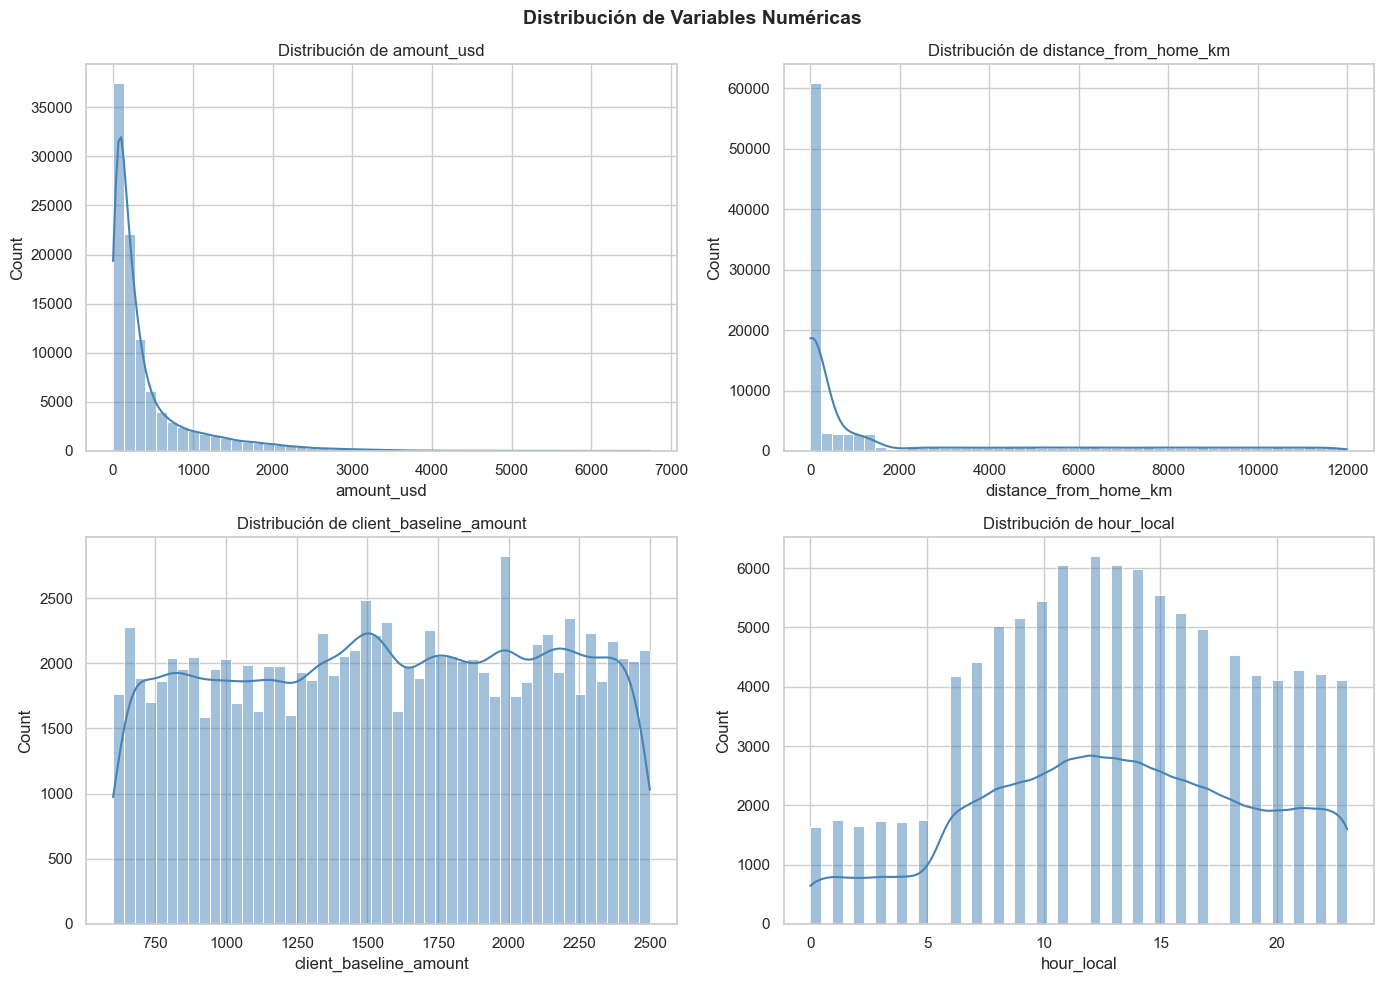

In [11]:
num_cols = ['amount_usd', 'distance_from_home_km', 'client_baseline_amount', 'hour_local']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i], color='steelblue') # type: ignore
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- `amount_usd`: distribución **muy sesgada a la derecha** (media=430, std=598, max=6,731). La mayoría de transacciones son montos pequeños (mediana=200 USD); los outliers de alto valor pueden ser indicadores de fraude.
- `distance_from_home_km`: distribución **bimodal** — la mediana es solo 21 km (la mayoría de transacciones ocurren cerca del hogar), pero la media sube a 1,779 km por el grupo de transacciones muy lejanas (Q3=1,365 km). Esta dispersión extrema es una señal de riesgo importante.
- `client_baseline_amount`: distribución aproximadamente **uniforme** entre 600 y 2,500 USD (media=1,567, std=546), sin sesgo marcado. Refleja el comportamiento típico de gasto del cliente.
- `hour_local`: distribución **unimodal con claro patrón horario** — actividad mínima de 0-5am (~1,650-1,760 tx/hora), sube bruscamente a las 6am (4,189), alcanza el pico entre 11h-13h (~6,000-6,200 tx/hora), y desciende gradualmente por la tarde/noche.

### Detección de Valores Extremos

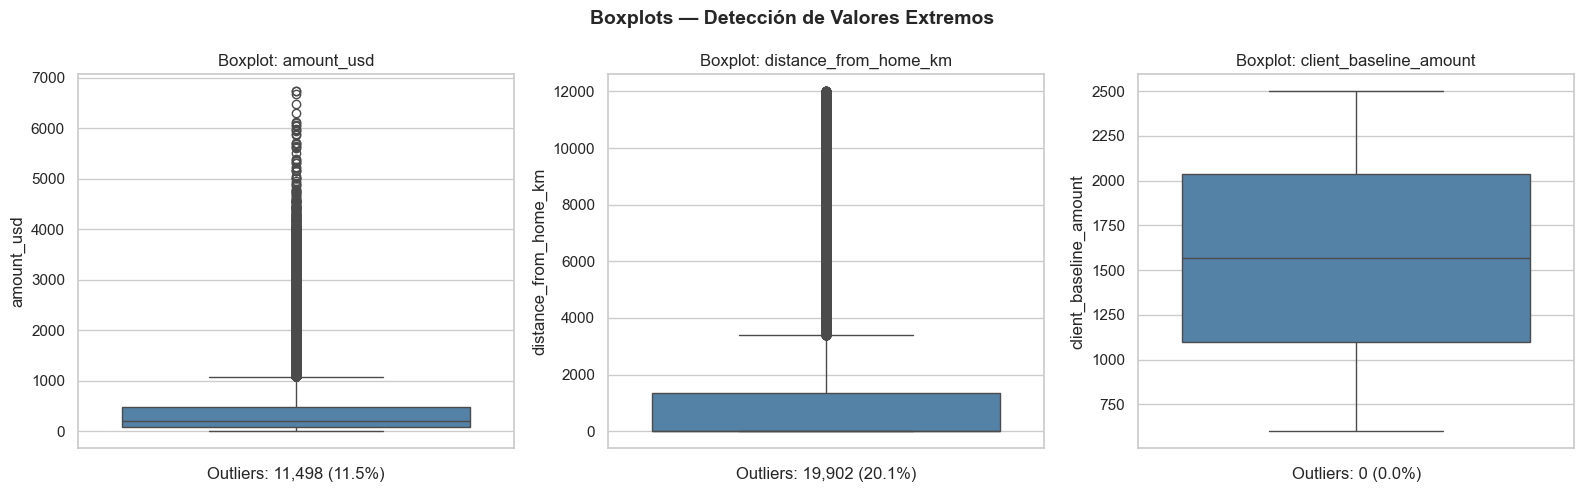

In [12]:
num_box_cols = ['amount_usd', 'distance_from_home_km', 'client_baseline_amount']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_box_cols):
    data = df[col].dropna()
    sns.boxplot(y=data, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot: {col}')
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).sum()
    axes[i].set_xlabel(f'Outliers: {outliers:,} ({outliers/len(data)*100:.1f}%)')

plt.suptitle('Boxplots — Detección de Valores Extremos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- `amount_usd` y `distance_from_home_km` presentan gran cantidad de outliers por encima del bigote superior (IQR × 1.5), lo que confirma el sesgo positivo de los histogramas.
- **Importante:** en detección de fraude, los outliers no deben eliminarse automáticamente — los valores extremos son con frecuencia los casos más sospechosos y contienen información discriminante valiosa.
- `client_baseline_amount` no muestra outliers extremos, lo que confirma su distribución más uniforme.

### Distribución Temporal de Transacciones

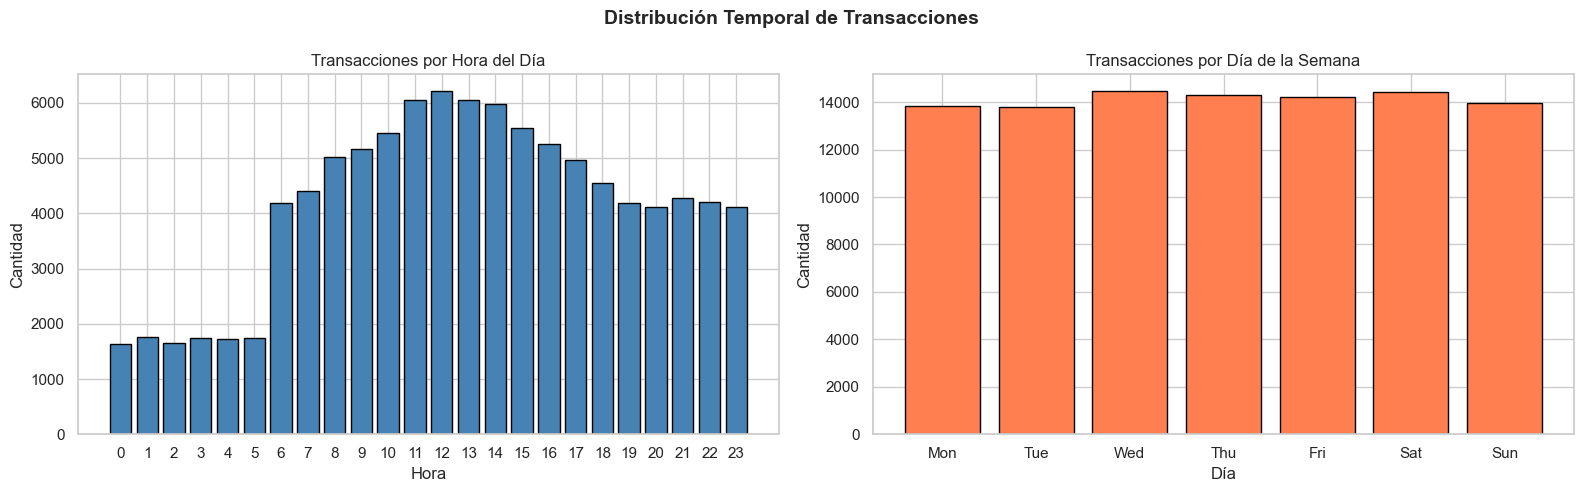

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_counts = df['hour_local'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Transacciones por Hora del Día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticks(range(0, 24))

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['day_of_week'].value_counts().reindex(day_order)
axes[1].bar(day_counts.index, day_counts.values, color='coral', edgecolor='black')
axes[1].set_title('Transacciones por Día de la Semana')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Cantidad')

plt.suptitle('Distribución Temporal de Transacciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- **Por hora:** la actividad es muy baja de madrugada (0-5am: ~1,650-1,760 tx/h), se dispara a las 6am (4,189), alcanza el pico entre 11h-13h (~6,050-6,210 tx/h) y disminuye paulatinamente hacia la noche. Patrón típico de horario bancario y de compras.
- **Por día de semana:** distribución prácticamente uniforme — miércoles y sábado lideran levemente (14,450 c/u), mientras lunes y martes son los días de menor actividad (~13,800). La diferencia entre el día más alto y el más bajo es menor al 5%, indicando que el sistema opera de forma constante toda la semana sin estacionalidad marcada.

### Distribución por Variables Categóricas

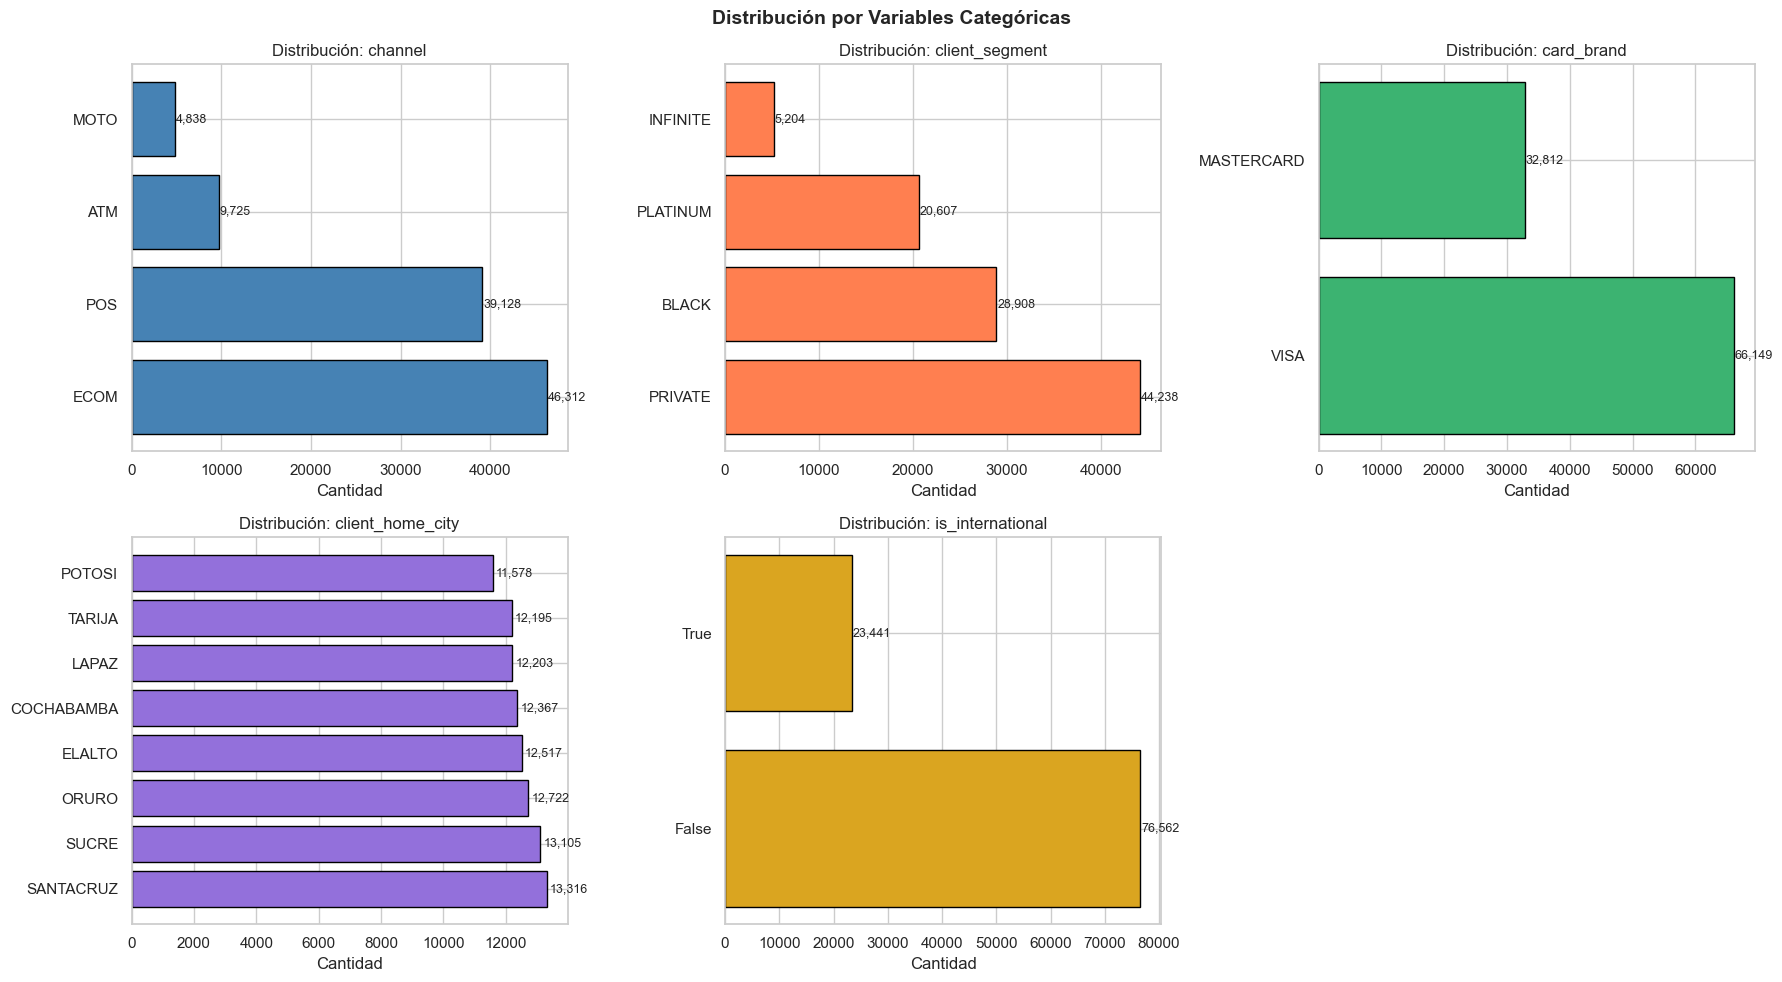

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_data = {
    'channel': df['channel'].value_counts(),
    'client_segment': df['client_segment'].value_counts(),
    'card_brand': df['card_brand'].value_counts(),
    'client_home_city': df['client_home_city'].value_counts(),
    'is_international': df['is_international'].value_counts(),
}
colors_cat = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']

for i, (col, counts) in enumerate(cat_data.items()):
    axes[i].barh(counts.index.astype(str), counts.values, color=colors_cat[i], edgecolor='black')
    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_xlabel('Cantidad')
    for j, v in enumerate(counts.values):
        axes[i].text(v + 100, j, f'{v:,}', va='center', fontsize=9)

axes[5].set_visible(False)
plt.suptitle('Distribución por Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- `channel`: ECOM domina con ~46% de transacciones, seguido de POS y ATM.
- `client_segment`: PRIVATE es el segmento más frecuente (~44%), seguido de PLATINUM.
- `card_brand`: VISA predomina sobre MASTERCARD (~66% vs ~33%).
- `client_home_city`: SANTACRUZ es la ciudad con más clientes, seguida de LAPAZ y SUCRE.
- `is_international`: ~76% de transacciones son nacionales, ~24% internacionales.

### Balance de Clases: Fraude vs No Fraude

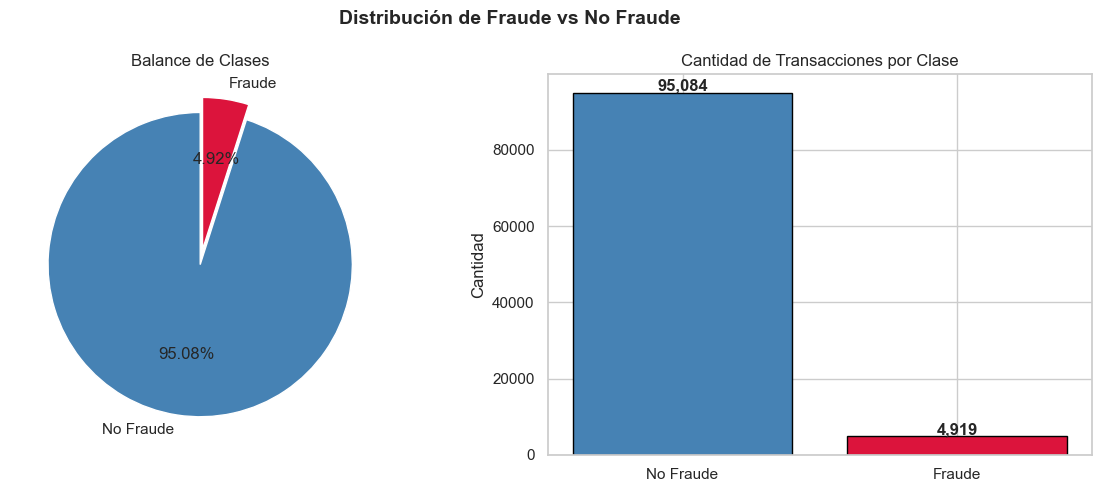

No Fraude: 95,084 (95.08%)
Fraude:    4,919  (4.92%)


In [15]:
fraud_counts = df['is_fraud'].value_counts()
labels = ['No Fraude', 'Fraude']
values = [fraud_counts[False], fraud_counts[True]]
colors_pie = ['steelblue', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(values, labels=labels, autopct='%1.2f%%', colors=colors_pie,
            startangle=90, explode=(0, 0.1))
axes[0].set_title('Balance de Clases')

axes[1].bar(labels, values, color=colors_pie, edgecolor='black')
axes[1].set_title('Cantidad de Transacciones por Clase')
axes[1].set_ylabel('Cantidad')
for i, v in enumerate(values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Distribución de Fraude vs No Fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"No Fraude: {fraud_counts[False]:,} ({fraud_counts[False]/len(df)*100:.2f}%)")
print(f"Fraude:    {fraud_counts[True]:,}  ({fraud_counts[True]/len(df)*100:.2f}%)")

**Observaciones:**
- El dataset presenta un **desbalance severo de clases**: solo ~4.9% son fraudes (≈4,919 casos de 100,003).
- Para modelos de clasificación esto requiere técnicas como **SMOTE**, undersampling, o `class_weight='balanced'`.
- Las métricas de evaluación deben priorizar **Recall, F1-score y AUC-ROC** sobre Accuracy — un modelo que siempre prediga "No Fraude" tendría 95.1% de accuracy sin detectar ningún fraude real.

### Distribución de Montos: Fraude vs No Fraude

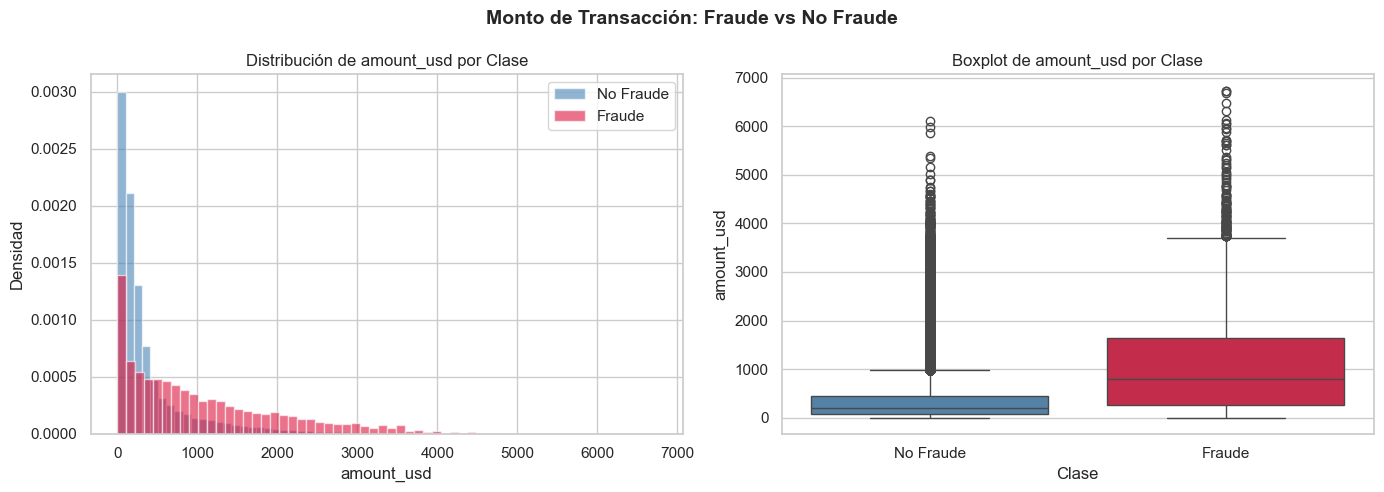

            count     mean      std   min     25%     50%      75%      max
is_fraud                                                                   
False     95084.0   395.91   541.17  0.29   82.23  191.98   440.63  6109.47
True       4919.0  1101.32  1064.67  0.07  267.63  788.66  1648.89  6731.90


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [(False, 'steelblue'), (True, 'crimson')]:
    data = df[df['is_fraud'] == label]['amount_usd'].dropna()
    axes[0].hist(data, bins=60, alpha=0.6, color=color,
                 label='No Fraude' if not label else 'Fraude', density=True)
axes[0].set_title('Distribución de amount_usd por Clase')
axes[0].set_xlabel('amount_usd')
axes[0].set_ylabel('Densidad')
axes[0].legend()

df_plot = df[['amount_usd', 'is_fraud']].copy()
df_plot['Clase'] = df_plot['is_fraud'].map({True: 'Fraude', False: 'No Fraude'})
sns.boxplot(data=df_plot, x='Clase', y='amount_usd',
            palette={'Fraude': 'crimson', 'No Fraude': 'steelblue'}, ax=axes[1],
            hue='Clase', legend=False)
axes[1].set_title('Boxplot de amount_usd por Clase')
axes[1].set_ylabel('amount_usd')

plt.suptitle('Monto de Transacción: Fraude vs No Fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('is_fraud')['amount_usd'].describe().round(2))

**Observaciones:**
- Las transacciones fraudulentas tienen un **monto significativamente mayor**: media $1,101 (fraude) vs $396 (legítima) — casi **3× más alto**.
- La mediana confirma la diferencia: $789 (fraude) vs $192 (legítima) — el monto es un **fuerte discriminante**.
- El fraude también tiene mayor dispersión (std=1,065 vs 541), con transacciones que van desde $0.07 hasta $6,732.
- `amount_usd` es una de las variables más predictivas para detección de fraude en este dataset.

### Distancia desde Hogar y Hora por Fraude

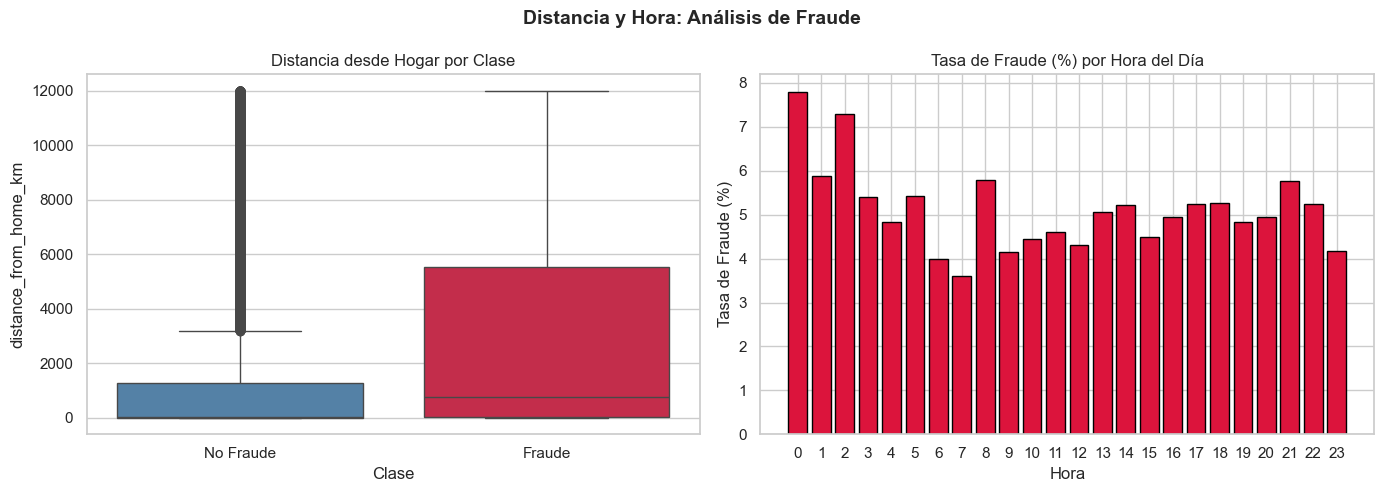

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df[['distance_from_home_km', 'is_fraud']].copy()
df_plot['Clase'] = df_plot['is_fraud'].map({True: 'Fraude', False: 'No Fraude'})
sns.boxplot(data=df_plot, x='Clase', y='distance_from_home_km',
            palette={'Fraude': 'crimson', 'No Fraude': 'steelblue'}, ax=axes[0],
            hue='Clase', legend=False)
axes[0].set_title('Distancia desde Hogar por Clase')
axes[0].set_ylabel('distance_from_home_km')

fraud_by_hour = df.groupby('hour_local')['is_fraud'].mean() * 100
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values, color='crimson', edgecolor='black')
axes[1].set_title('Tasa de Fraude (%) por Hora del Día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Tasa de Fraude (%)')
axes[1].set_xticks(range(0, 24))

plt.suptitle('Distancia y Hora: Análisis de Fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- **Distancia:** la mediana de `distance_from_home_km` en fraudes es **782 km** vs solo **21 km** en legítimas — diferencia de **37×**. El Q3 de fraudes alcanza 5,535 km vs 1,288 km para legítimas. `distance_from_home_km` es el predictor más fuerte del dataset.
- **Tasa de fraude por hora:** los fraudes son más frecuentes en **madrugada** — hora 0 lidera con **7.8%** de tasa, seguida de hora 2 (7.3%) y hora 1 (5.9%). El horario de menor fraude es 7am (3.6%) y 6am (4.0%), coincidiendo con las horas de menor actividad absoluta. El patrón sugiere que los defraudadores actúan cuando el cliente duerme y no puede alertar al banco.

### Variables Categóricas por Fraude

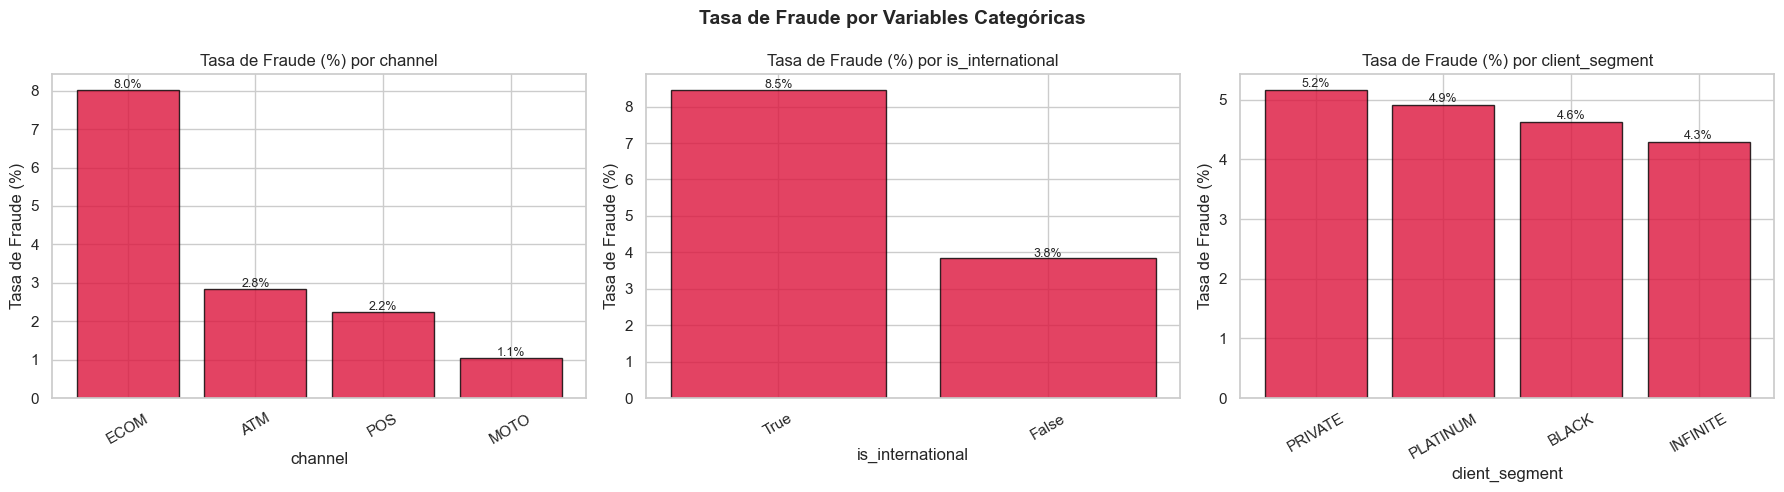

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_fraud_cols = ['channel', 'is_international', 'client_segment']
for i, col in enumerate(cat_fraud_cols):
    fraud_rate = df.groupby(col)['is_fraud'].mean() * 100
    fraud_rate = fraud_rate.sort_values(ascending=False)
    axes[i].bar(fraud_rate.index.astype(str), fraud_rate.values,
                color='crimson', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Tasa de Fraude (%) por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Tasa de Fraude (%)')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(fraud_rate.values):
        axes[i].text(j, v + 0.05, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Tasa de Fraude por Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones:**
- **Canal:** ECOM tiene la tasa de fraude más alta con **8.0%**, muy por encima de ATM (2.8%), POS (2.2%) y MOTO (1.1%). Las compras en línea son el principal vector de fraude, posiblemente por ausencia de autenticación física (chip/PIN).
- **Internacional:** transacciones internacionales tienen **8.5%** de tasa de fraude vs 3.8% nacionales — más del doble. Combinado con `distance_from_home_km`, confirma que la geolocalización es clave para detectar fraude.
- **Segmento:** las diferencias entre segmentos son pequeñas (PRIVATE 5.2%, PLATINUM 4.9%, BLACK 4.6%, INFINITE 4.3%). El segmento no es un discriminante fuerte por sí solo, aunque PRIVATE lidera levemente.

---
# Fase 3: Balanceo de clases y análisis de fraude

In [19]:
# Conteo de clases (ítem 1)
fraud_counts = df['is_fraud'].value_counts()
print("=== Conteo de clases ===")
print(f"No Fraude (False): {fraud_counts[False]:>7,}")
print(f"Fraude    (True) : {fraud_counts[True]:>7,}")

# Porcentaje de cada clase (ítem 2)
total = len(df)
pct_fraud = fraud_counts[True]  / total * 100
pct_legit  = fraud_counts[False] / total * 100
print(f"\n=== Porcentaje ===")
print(f"No Fraude: {pct_legit:.2f}%")
print(f"Fraude:    {pct_fraud:.2f}%")


=== Conteo de clases ===
No Fraude (False):  95,084
Fraude    (True) :   4,919

=== Porcentaje ===
No Fraude: 95.08%
Fraude:    4.92%


### Proporción y Evaluación del Desbalance

In [20]:
# Proporción legítimas:fraudes (ítem 4)
ratio = fraud_counts[False] / fraud_counts[True]
print(f"Proporción legítimas:fraudes = {ratio:.1f}:1")
print(f"Por cada transacción fraudulenta hay {ratio:.1f} legítimas.\n")

# Evaluación del nivel de desbalance (ítem 5)
print("=== Evaluación del desbalance ===")
if pct_fraud < 1:
    nivel = "EXTREMO (< 1%)"
elif pct_fraud < 5:
    nivel = "ALTO (1% – 5%)"
elif pct_fraud < 20:
    nivel = "MODERADO (5% – 20%)"
else:
    nivel = "LEVE (> 20%)"
print(f"Tasa de fraude: {pct_fraud:.2f}%  →  Desbalance {nivel}")

Proporción legítimas:fraudes = 19.3:1
Por cada transacción fraudulenta hay 19.3 legítimas.

=== Evaluación del desbalance ===
Tasa de fraude: 4.92%  →  Desbalance ALTO (1% – 5%)


---
# Fase 4: Selección de Features — Fraude en Venues de Entretenimiento

**Contexto:** El objetivo es detectar fraude en comercios de entretenimiento (cines, conciertos, bares, restaurantes).
Se priorizan variables de ubicación geográfica, tipo de comercio (MCC), temporales, perfil del comprador y seguridad de la transacción.

### Criterios de eliminación
| Criterio | Descripción |
|----------|-------------|
| **Constante** | Mismo valor en todas las filas — zero variance |
| **Casi constante** | Un único valor válido (~99 %) en todo el dataset |
| **Identificador único** | UUID o número secuencial por transacción — el modelo lo memoriza sin generalizar |
| **Redundante** | La misma información ya existe en una columna más limpia |

> `DE7_transmission_datetime` y `DE12_local_time` se **conservan** porque pueden servir para extraer
> features adicionales de día y hora con mayor granularidad que las columnas derivadas.

### Eliminación de columnas no importantes

In [21]:
# delete columns which only hold NaN values
print("Columns with only nulls: ", columns_with_only_nulls)
df.drop(columns=columns_with_only_nulls, inplace=True)

Columns with only nulls:  ['DE48_additional_data', 'DE54_additional_amounts', 'DE56_original_data', 'DE103_account_id_2']


### Llenar valores nulos

In [22]:
# fill categorical data 
df = df.assign(
    client_segment=df['client_segment'].fillna('UNKNOWN'),
    card_brand=df['card_brand'].fillna('UNKNOWN'),
    DE44_additional_response_data=df['DE44_additional_response_data'].fillna('UNKNOWN'),
    day_of_week=df['day_of_week'].fillna('Unk'),
    response_description=df['response_description'].fillna('Unknown'),
    DE63_network_specific=df['DE63_network_specific'].fillna('Other')
)

In [23]:
# fill numerical data
df = df.assign(
    DE9_conversion_rate_billing=df['DE9_conversion_rate_billing'].fillna(
        df['DE9_conversion_rate_billing'].median()
    ),
    DE15_settlement_date=df['DE15_settlement_date'].fillna(
        df['DE15_settlement_date'].median()
    ),
    DE23_card_seq_number=df['DE23_card_seq_number'].fillna(
        df['DE23_card_seq_number'].median()
    ),
    DE58_authorizing_agent_id=df['DE58_authorizing_agent_id'].fillna(0),
    DE61_pos_extended_data=df['DE61_pos_extended_data'].fillna(
        df['DE61_pos_extended_data'].median()
    ),
    DE100_receiving_institution_id=df['DE100_receiving_institution_id'].fillna(0),
    distance_from_home_km=df['distance_from_home_km'].fillna(
        df['distance_from_home_km'].median()
    )
)

In [24]:
# Needs some other handling 
df = df.assign(
    DE35_track2_data_masked=df['DE35_track2_data_masked'].fillna(
        df['DE35_track2_data_masked'].mode()[0]
    ),
    DE38_authorization_code=df['DE38_authorization_code'].fillna(
        df['DE38_authorization_code'].mode()[0]
    ),
    DE41_terminal_id=df['DE41_terminal_id'].fillna(
        df['DE41_terminal_id'].mode()[0]
    ),
    DE42_card_acceptor_id=df['DE42_card_acceptor_id'].fillna(
        df['DE42_card_acceptor_id'].mode()[0]
    ),
    DE102_account_id_1=df['DE102_account_id_1'].fillna(
        df['DE102_account_id_1'].mode()[0]
    ),
    DE123_pos_data_code=df['DE123_pos_data_code'].fillna(
        df['DE123_pos_data_code'].mode()[0]
    )
)

---
## Fase 6 - MODELO V1 LightGBM para fraude en entretenimiento

El MODELO V1 trabaja con **`dataset de entretenimiento.csv`**, un archivo con transacciones de los rubros definidos para entretenimiento.

El rubro de comercio se identifica con **`DE18_merchant_category_code`**. `DE14_expiration_date` no se usa como rubro porque corresponde a la fecha de expiracion de la tarjeta.

**MCC incluidos:** `4511`, `4816`, `5611`, `5651`, `5812`, `5814`, `5921`, `7011`, `7832`, `7995`.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve,
)

TARGET = "is_fraud"
RANDOM_STATE = 42
GLOBAL_DATASET_CANDIDATES = [
    Path("Documentos/Copia de Datasets 3 bancos/Copia de 01_bo_vip_seed22_n100000.csv"),
    Path("Documentos/Copia de 01_bo_vip_seed22_n100000.csv"),
]
ENTERTAINMENT_DATASET_PATH = Path("dataset de entretenimiento.csv")

ENTERTAINMENT_MCCS = {
    4511: "Aerolineas / viajes",
    4816: "Servicios online / streaming",
    5611: "Ropa masculina",
    5651: "Ropa familiar",
    5812: "Restaurantes",
    5814: "Fast Food",
    5921: "Licorerias / vinos",
    7011: "Hoteles",
    7832: "Cine",
    7995: "Casino / apuestas",
}

LEAKAGE_COLS = [
    "approved", "DE39_response_code", "response_description",
    "DE38_authorization_code", "DE44_additional_response_data",
]

ID_MEMORIZATION_COLS = [
    "transaction_id", "pan_masked", "pan_hash", "DE2_PAN", "DE11_STAN",
    "DE35_track2_data_masked", "DE37_retrieval_reference_number", "DE102_account_id_1",
]

EMPTY_OR_CONSTANT_COLS = [
    "DE48_additional_data", "DE54_additional_amounts", "DE56_original_data", "DE103_account_id_2",
    "bank_code", "bank_name", "bank_country", "bank_tier", "MTI",
    "DE32_acquiring_institution_id", "DE50_currency_code_settlement", "DE51_currency_code_billing",
    "DE58_authorizing_agent_id", "DE63_network_specific", "DE100_receiving_institution_id",
]

BASE_NUMERIC_FEATURES_V1 = [
    "amount_usd", "client_baseline_amount", "distance_from_home_km",
    "hour_local", "DE9_conversion_rate_billing",
]

BASE_CATEGORICAL_FEATURES_V1 = [
    "channel", "DE18_merchant_category_code", "DE22_pos_entry_mode", "DE25_pos_condition_code",
    "DE52_pin_data_present", "DE55_emv_data_present", "DE60_pos_terminal_type",
    "client_segment", "card_brand", "client_home_city", "is_international",
]

FREQ_ENCODE_COLS_V1 = ["DE41_terminal_id", "DE42_card_acceptor_id", "client_home_city", "DE18_merchant_category_code"]
DERIVED_NUMERIC_FEATURES_V1 = [
    "amount_to_baseline", "amount_usd_log", "high_amount_vs_baseline",
    "distance_log", "is_far_from_home", "is_night", "is_weekend",
    "hour_sin", "hour_cos", "is_card_not_present", "pin_present",
    "emv_present", "is_international_int",
]
FREQ_FEATURES_V1 = [f"{col}_freq" for col in FREQ_ENCODE_COLS_V1]


### Funciones del pipeline V1

Estas funciones crean el CSV de entretenimiento, cargan ese archivo como fuente del modelo, limpian columnas no utiles y construyen features derivadas sin usar informacion posterior a la autorizacion.


In [2]:
def _find_global_dataset_path():
    for dataset_path in GLOBAL_DATASET_CANDIDATES:
        if dataset_path.exists():
            return dataset_path
    raise FileNotFoundError("No se encontro el CSV BO-VIP global esperado en Documentos/.")


def _assign_split(month):
    if month in [1, 2, 3, 4]:
        return "train"
    if month == 5:
        return "validation"
    if month == 6:
        return "test"
    return "out_of_scope"


def create_entertainment_dataset_csv(output_path=ENTERTAINMENT_DATASET_PATH):
    """Filtra el BO-VIP global por MCC de entretenimiento, enero-junio, y guarda el CSV base de V1."""
    source_path = _find_global_dataset_path()
    df_global = pd.read_csv(source_path, sep=";")
    df_global[TARGET] = df_global[TARGET].astype(bool)
    df_global["month"] = (df_global["DE13_local_date"] // 100).astype(int)

    df_entertainment = df_global[
        df_global["DE18_merchant_category_code"].isin(ENTERTAINMENT_MCCS.keys())
        & df_global["month"].between(1, 6)
    ].copy()
    df_entertainment["mcc_name"] = df_entertainment["DE18_merchant_category_code"].map(ENTERTAINMENT_MCCS)
    df_entertainment["split"] = df_entertainment["month"].map(_assign_split)

    # Dejar auxiliares cerca de las columnas base para lectura humana.
    helper_cols = ["mcc_name", "month", "split"]
    ordered_cols = helper_cols + [col for col in df_entertainment.columns if col not in helper_cols]
    df_entertainment = df_entertainment[ordered_cols]
    df_entertainment.to_csv(output_path, index=False, encoding="utf-8")
    return df_entertainment, source_path, Path(output_path)


def load_entertainment_dataset(path=ENTERTAINMENT_DATASET_PATH):
    """Carga exclusivamente el CSV de entretenimiento usado por el MODELO V1."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No existe {path}. Ejecuta create_entertainment_dataset_csv() primero.")
    df = pd.read_csv(path)
    df[TARGET] = df[TARGET].astype(bool)
    df["month"] = df["month"].astype(int)
    return df, path


def clean_entertainment_columns(df_entertainment):
    """Selecciona columnas utiles para V1 y deja fuera leakage, IDs y columnas sin variacion."""
    required_cols = (
        [TARGET, "month", "split", "mcc_name", "day_of_week"]
        + BASE_NUMERIC_FEATURES_V1
        + BASE_CATEGORICAL_FEATURES_V1
        + FREQ_ENCODE_COLS_V1
    )
    required_cols = list(dict.fromkeys([col for col in required_cols if col in df_entertainment.columns]))
    df_model = df_entertainment[required_cols].copy()

    dropped_by_policy = [
        col for col in (LEAKAGE_COLS + ID_MEMORIZATION_COLS + EMPTY_OR_CONSTANT_COLS)
        if col in df_entertainment.columns and col not in df_model.columns
    ]

    constant_cols = []
    for col in list(df_model.columns):
        if col not in [TARGET, "split", "month", "mcc_name"] and df_model[col].nunique(dropna=False) <= 1:
            constant_cols.append(col)
    df_model = df_model.drop(columns=constant_cols)

    return df_model, dropped_by_policy, constant_cols


def temporal_train_val_test_split(df_model):
    """Train enero-abril, validacion mayo, test junio, usando la columna split del CSV."""
    df_train = df_model[df_model["split"] == "train"].copy()
    df_val = df_model[df_model["split"] == "validation"].copy()
    df_test = df_model[df_model["split"] == "test"].copy()
    return df_train, df_val, df_test


def _truthy_flag(series):
    return series.astype(str).str.upper().isin(["Y", "YES", "TRUE", "1", "SI", "S"]).astype("int8")


def _add_derived_features(frame):
    frame = frame.copy()
    frame["amount_to_baseline"] = frame["amount_usd"] / (frame["client_baseline_amount"] + 1.0)
    frame["amount_usd_log"] = np.log1p(frame["amount_usd"].clip(lower=0))
    frame["high_amount_vs_baseline"] = (frame["amount_to_baseline"] >= 3.0).astype("int8")
    frame["distance_log"] = np.log1p(frame["distance_from_home_km"].clip(lower=0))
    frame["is_far_from_home"] = (frame["distance_from_home_km"] >= 500).astype("int8")
    frame["is_night"] = ((frame["hour_local"] >= 22) | (frame["hour_local"] < 6)).astype("int8")
    frame["is_weekend"] = frame["day_of_week"].isin(["Sat", "Sun", "Saturday", "Sunday", "sabado", "domingo"]).astype("int8")
    frame["hour_sin"] = np.sin(2 * np.pi * frame["hour_local"] / 24)
    frame["hour_cos"] = np.cos(2 * np.pi * frame["hour_local"] / 24)
    frame["is_card_not_present"] = (
        frame["channel"].astype(str).str.upper().isin(["ECOM", "MOTO"])
        | frame["DE25_pos_condition_code"].astype(str).isin(["1", "01", "8", "08", "59"])
        | frame["DE22_pos_entry_mode"].astype(str).isin(["81", "081"])
    ).astype("int8")
    frame["pin_present"] = _truthy_flag(frame["DE52_pin_data_present"])
    frame["emv_present"] = _truthy_flag(frame["DE55_emv_data_present"])
    frame["is_international_int"] = _truthy_flag(frame["is_international"])
    return frame


def build_v1_features(df_train, df_val, df_test):
    """Construye X/y para V1 ajustando imputacion y acumuladores/frecuencias solo con train."""
    train = df_train.copy()
    val = df_val.copy()
    test = df_test.copy()

    numeric_fit_cols = [col for col in BASE_NUMERIC_FEATURES_V1 if col in train.columns]
    train_medians = train[numeric_fit_cols].median(numeric_only=True)
    for frame in (train, val, test):
        for col in numeric_fit_cols:
            frame[col] = frame[col].fillna(train_medians[col])
        frame["day_of_week"] = frame["day_of_week"].fillna("UNKNOWN")
        for col in set(BASE_CATEGORICAL_FEATURES_V1 + FREQ_ENCODE_COLS_V1):
            if col in frame.columns:
                frame[col] = frame[col].fillna("UNKNOWN")

    train = _add_derived_features(train)
    val = _add_derived_features(val)
    test = _add_derived_features(test)

    freq_features = []
    for col in FREQ_ENCODE_COLS_V1:
        if col in train.columns:
            freq_map = train[col].value_counts(dropna=False)
            freq_col = f"{col}_freq"
            train[freq_col] = train[col].map(freq_map).astype("float32")
            val[freq_col] = val[col].map(freq_map).fillna(0).astype("float32")
            test[freq_col] = test[col].map(freq_map).fillna(0).astype("float32")
            freq_features.append(freq_col)

    categorical_features = [col for col in BASE_CATEGORICAL_FEATURES_V1 if col in train.columns]
    numeric_features = numeric_fit_cols + DERIVED_NUMERIC_FEATURES_V1 + freq_features
    final_features = list(dict.fromkeys(numeric_features + categorical_features))

    for col in categorical_features:
        train[col] = train[col].astype("category")
        val[col] = pd.Categorical(val[col], categories=train[col].cat.categories)
        test[col] = pd.Categorical(test[col], categories=train[col].cat.categories)

    X_train = train[final_features].copy()
    y_train = train[TARGET].astype(int)
    X_val = val[final_features].copy()
    y_val = val[TARGET].astype(int)
    X_test = test[final_features].copy()
    y_test = test[TARGET].astype(int)

    return X_train, y_train, X_val, y_val, X_test, y_test, final_features, categorical_features


def train_lgbm_v1(X_train, y_train, categorical_features):
    """Entrena el MODELO V1 especialista con LightGBM."""
    positives = int(y_train.sum())
    negatives = int((y_train == 0).sum())
    scale_pos_weight_v1 = negatives / max(positives, 1)

    model_v1 = LGBMClassifier(
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.85,
        reg_alpha=0.10,
        reg_lambda=0.50,
        scale_pos_weight=scale_pos_weight_v1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    model_v1.fit(X_train, y_train, categorical_feature=categorical_features)
    return model_v1, scale_pos_weight_v1


def _best_f1_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    if len(thresholds) == 0:
        return 0.5, 0.0, 0.0, 0.0
    f1_values = 2 * precision * recall / (precision + recall + 1e-12)
    best_idx = int(np.nanargmax(f1_values[:-1]))
    return float(thresholds[best_idx]), float(f1_values[best_idx]), float(precision[best_idx]), float(recall[best_idx])


def evaluate_v1(model_v1, X_val, y_val, X_test, y_test):
    """Calibra threshold por F1 en validacion y evalua junio."""
    val_proba = model_v1.predict_proba(X_val)[:, 1]
    best_thr, val_f1, val_precision, val_recall = _best_f1_threshold(y_val, val_proba)

    test_proba = model_v1.predict_proba(X_test)[:, 1]
    y_pred = (test_proba >= best_thr).astype(int)

    auc_roc = roc_auc_score(y_test, test_proba) if y_test.nunique() == 2 else np.nan
    f1 = f1_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    print("=== Umbral seleccionado en validacion (mayo) ===")
    print(f"Threshold V1: {best_thr:.4f}")
    print(f"F1_val={val_f1:.4f} | Precision_val={val_precision:.4f} | Recall_val={val_recall:.4f}")
    print()
    print("=== MODELO V1 - Test final entretenimiento (junio) ===")
    print(f"AUC-ROC: {auc_roc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Precision fraude: {precision:.4f}")
    print(f"Recall fraude: {recall:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["No Fraude", "Fraude"], digits=4, zero_division=0))
    print("Matriz de confusion [real x predicho]:")
    print(pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=["Real No Fraude", "Real Fraude"],
        columns=["Predice No Fraude", "Predice Fraude"],
    ))
    print()
    print("Resumen operativo sobre junio:")
    print(f"  Fraudes reales:             {int(y_test.sum()):>5}")
    print(f"  Fraudes detectados (TP):    {tp:>5} ({tp / max(int(y_test.sum()), 1) * 100:.1f}%)")
    print(f"  Fraudes no detectados (FN): {fn:>5} ({fn / max(int(y_test.sum()), 1) * 100:.1f}%)")
    print(f"  Falsos positivos (FP):      {fp:>5}")
    print(f"  Legitimas correctas (TN):   {tn:>5}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No Fraude", "Fraude"],
        cmap="Blues", colorbar=False, ax=axes[0],
    )
    axes[0].set_title(f"Matriz de confusion V1 | thr={best_thr:.4f}")

    fpr, tpr, _ = roc_curve(y_test, test_proba)
    axes[1].plot(fpr, tpr, color="darkgreen", lw=2.5, label=f"AUC-ROC={auc_roc:.4f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[1].set_title("Curva ROC V1 - dataset de entretenimiento")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "threshold": best_thr,
        "auc_roc": auc_roc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "test_proba": test_proba,
        "test_pred": y_pred,
    }


### Perfil del dataset de entretenimiento

Se valida el volumen de transacciones, fraudes, no fraudes, MCC incluidos y split temporal que se usara para el MODELO V1.


In [27]:
df_entertainment_created, global_source_path_v1, entertainment_csv_path_v1 = create_entertainment_dataset_csv()
df_entertainment_v1, loaded_entertainment_path_v1 = load_entertainment_dataset(entertainment_csv_path_v1)

print(f"CSV global origen: {global_source_path_v1}")
print(f"CSV de entretenimiento creado y cargado: {loaded_entertainment_path_v1.resolve()}")
print(f"Filas dataset de entretenimiento: {len(df_entertainment_v1):,}")
print(f"Fraudes: {int(df_entertainment_v1[TARGET].sum()):,}")
print(f"No fraudes: {int((~df_entertainment_v1[TARGET]).sum()):,}")
print(f"Tasa de fraude: {df_entertainment_v1[TARGET].mean()*100:.3f}%")
print(f"MCC usados: {sorted(df_entertainment_v1['DE18_merchant_category_code'].unique().tolist())}")
print(f"Meses usados: {sorted(df_entertainment_v1['month'].unique().tolist())}")
print(f"Splits: {df_entertainment_v1['split'].value_counts().to_dict()}")

mcc_summary_v1 = (
    df_entertainment_v1
    .groupby(["DE18_merchant_category_code", "mcc_name"], observed=True)[TARGET]
    .agg(transacciones="size", fraudes="sum", no_fraudes=lambda s: int((~s.astype(bool)).sum()), tasa_fraude=lambda s: s.mean() * 100)
    .reset_index()
)
display(mcc_summary_v1)

split_summary_v1 = (
    df_entertainment_v1
    .groupby(["split", "month"], observed=True)[TARGET]
    .agg(transacciones="size", fraudes="sum", no_fraudes=lambda s: int((~s.astype(bool)).sum()), tasa_fraude=lambda s: s.mean() * 100)
    .reset_index()
)
display(split_summary_v1)


CSV global origen: Documentos\Copia de Datasets 3 bancos\Copia de 01_bo_vip_seed22_n100000.csv
CSV de entretenimiento creado y cargado: C:\Users\javil\OneDrive\Documentos\U\Secuity Data Science\PlusTI\dataset de entretenimiento.csv
Filas dataset de entretenimiento: 45,091
Fraudes: 1,990
No fraudes: 43,101
Tasa de fraude: 4.413%
MCC usados: [4511, 4816, 5611, 5651, 5812, 5814, 5921, 7011, 7832, 7995]
Meses usados: [1, 2, 3, 4, 5, 6]
Splits: {'train': 30110, 'validation': 7800, 'test': 7181}


,DE18_merchant_category_code,mcc_name,transacciones,fraudes,no_fraudes,tasa_fraude
0,4511,Aerolineas / viajes,9181,414,8767,4.509313
1,4816,Servicios online / streaming,5100,621,4479,12.176471
2,5611,Ropa masculina,1106,24,1082,2.169982
3,5651,Ropa familiar,7686,77,7609,1.001821
4,5812,Restaurantes,4521,34,4487,0.752046
5,5814,Fast Food,2356,17,2339,0.721562
6,5921,Licorerias / vinos,3362,32,3330,0.951814
7,7011,Hoteles,9059,415,8644,4.581080
8,7832,Cine,2380,19,2361,0.798319
9,7995,Casino / apuestas,340,337,3,99.117647


,split,month,transacciones,fraudes,no_fraudes,tasa_fraude
0,test,6,7181,305,6876,4.247319
1,train,1,7873,371,7502,4.712308
2,train,2,7085,320,6765,4.516584
3,train,3,7673,350,7323,4.561449
4,train,4,7479,296,7183,3.957748
5,validation,5,7800,348,7452,4.461538


### Visualizacion del dataset de entretenimiento

Estas graficas describen el balance fraude/no fraude, el comportamiento por MCC, la distribucion mensual y las senales operativas relevantes.


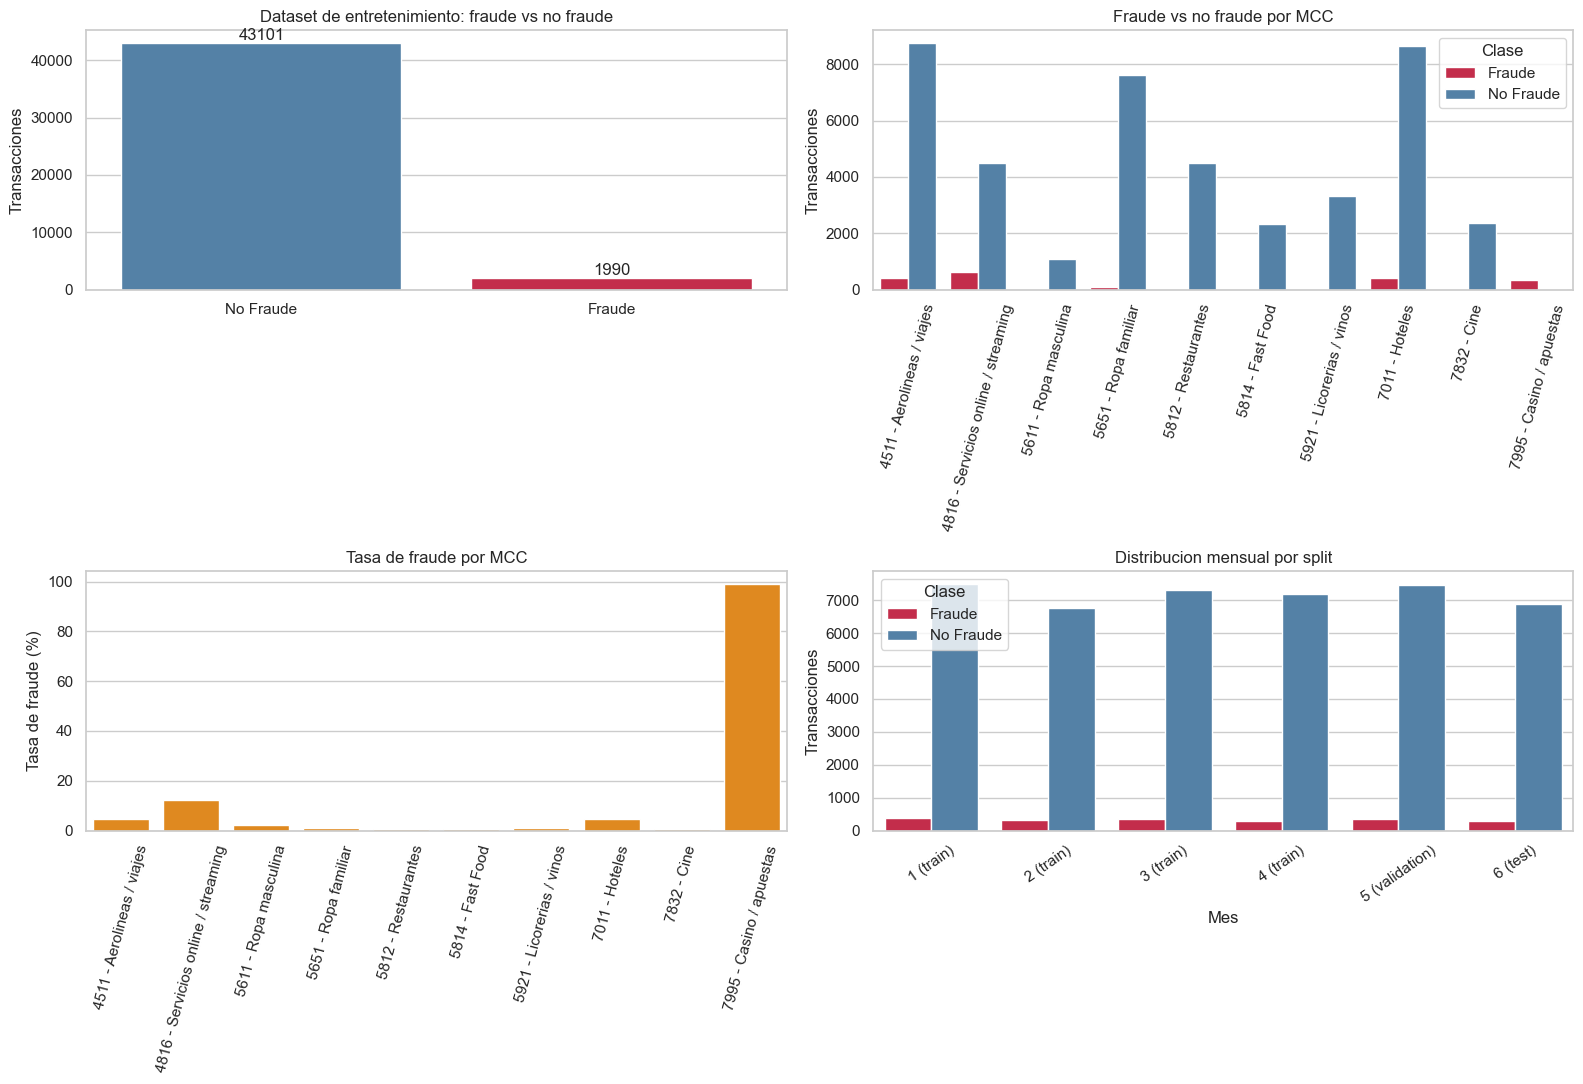

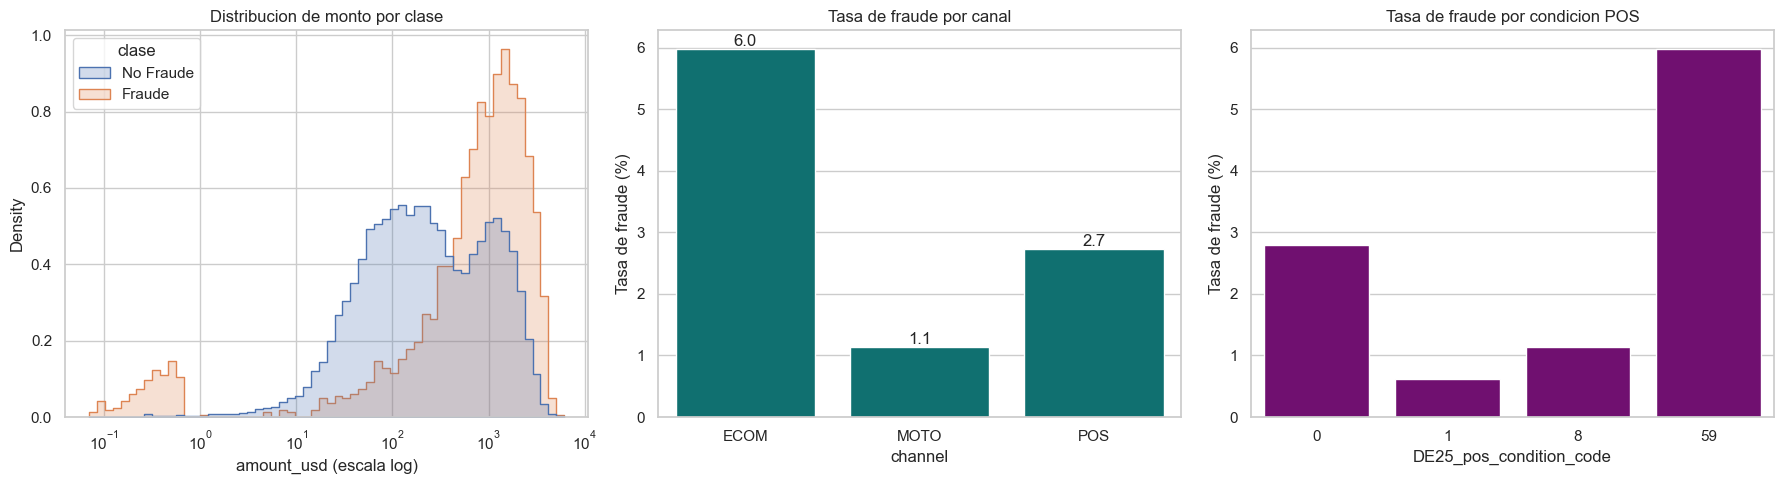

In [28]:
plot_df = df_entertainment_v1.copy()
plot_df["clase"] = plot_df[TARGET].map({False: "No Fraude", True: "Fraude"})

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1) Balance total fraude/no fraude
sns.countplot(data=plot_df, x="clase", hue="clase", palette={"No Fraude": "steelblue", "Fraude": "crimson"}, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Dataset de entretenimiento: fraude vs no fraude")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Transacciones")
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt="%d")

# 2) Fraude/no fraude por MCC
mcc_counts = plot_df.groupby(["DE18_merchant_category_code", "mcc_name", "clase"], observed=True).size().reset_index(name="count")
mcc_counts["mcc_label"] = mcc_counts["DE18_merchant_category_code"].astype(str) + " - " + mcc_counts["mcc_name"]
sns.barplot(data=mcc_counts, x="mcc_label", y="count", hue="clase", palette={"No Fraude": "steelblue", "Fraude": "crimson"}, ax=axes[0, 1])
axes[0, 1].set_title("Fraude vs no fraude por MCC")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Transacciones")
axes[0, 1].tick_params(axis="x", rotation=75)
axes[0, 1].legend(title="Clase")

# 3) Tasa de fraude por MCC
rate_by_mcc = plot_df.groupby(["DE18_merchant_category_code", "mcc_name"], observed=True)[TARGET].mean().mul(100).reset_index(name="tasa_fraude")
rate_by_mcc["mcc_label"] = rate_by_mcc["DE18_merchant_category_code"].astype(str) + " - " + rate_by_mcc["mcc_name"]
sns.barplot(data=rate_by_mcc, x="mcc_label", y="tasa_fraude", color="darkorange", ax=axes[1, 0])
axes[1, 0].set_title("Tasa de fraude por MCC")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Tasa de fraude (%)")
axes[1, 0].tick_params(axis="x", rotation=75)

# 4) Mes/split fraude/no fraude
monthly_counts = plot_df.groupby(["month", "split", "clase"], observed=True).size().reset_index(name="count")
monthly_counts["month_split"] = monthly_counts["month"].astype(str) + " (" + monthly_counts["split"] + ")"
sns.barplot(data=monthly_counts, x="month_split", y="count", hue="clase", palette={"No Fraude": "steelblue", "Fraude": "crimson"}, ax=axes[1, 1])
axes[1, 1].set_title("Distribucion mensual por split")
axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Transacciones")
axes[1, 1].tick_params(axis="x", rotation=35)
axes[1, 1].legend(title="Clase")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=plot_df, x="amount_usd", hue="clase", bins=60, log_scale=True, common_norm=False, stat="density", element="step", ax=axes[0])
axes[0].set_title("Distribucion de monto por clase")
axes[0].set_xlabel("amount_usd (escala log)")

channel_rate = plot_df.groupby("channel", observed=True)[TARGET].agg(transacciones="size", tasa_fraude=lambda s: s.mean()*100).reset_index()
sns.barplot(data=channel_rate, x="channel", y="tasa_fraude", color="teal", ax=axes[1])
axes[1].set_title("Tasa de fraude por canal")
axes[1].set_ylabel("Tasa de fraude (%)")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f")

pos_rate = plot_df.groupby("DE25_pos_condition_code", observed=True)[TARGET].agg(transacciones="size", tasa_fraude=lambda s: s.mean()*100).reset_index()
pos_rate["DE25_pos_condition_code"] = pos_rate["DE25_pos_condition_code"].astype(str)
sns.barplot(data=pos_rate, x="DE25_pos_condition_code", y="tasa_fraude", color="purple", ax=axes[2])
axes[2].set_title("Tasa de fraude por condicion POS")
axes[2].set_xlabel("DE25_pos_condition_code")
axes[2].set_ylabel("Tasa de fraude (%)")

plt.tight_layout()
plt.show()


### Entrenamiento del MODELO V1

El split temporal queda fijo: enero-abril para entrenar, mayo para seleccionar threshold y junio para test final.


In [29]:
df_model_v1, dropped_cols_v1, constant_cols_v1 = clean_entertainment_columns(df_entertainment_v1)
df_train_v1, df_val_v1, df_test_v1 = temporal_train_val_test_split(df_model_v1)

print("Columnas eliminadas por politica V1:")
print(dropped_cols_v1)
print("Columnas excluidas por quedar constantes en dataset de entretenimiento:")
print(constant_cols_v1)
print()
print("Split temporal V1 desde dataset de entretenimiento.csv:")
for name, frame in [("Train enero-abril", df_train_v1), ("Validacion mayo", df_val_v1), ("Test junio", df_test_v1)]:
    print(f"  {name}: {len(frame):>6,} tx | fraudes={int(frame[TARGET].sum()):>4} | no fraudes={int((~frame[TARGET]).sum()):>6} | tasa={frame[TARGET].mean()*100:.3f}%")

X_train_v1, y_train_v1, X_val_v1, y_val_v1, X_test_v1, y_test_v1, FINAL_FEATURES_V1, CATEGORICAL_FEATURES_V1 = build_v1_features(
    df_train_v1, df_val_v1, df_test_v1
)

requested_mcc_v1 = set(ENTERTAINMENT_MCCS.keys())
assert set(X_train_v1["DE18_merchant_category_code"].astype(int).unique()).issubset(requested_mcc_v1)
assert set(X_val_v1["DE18_merchant_category_code"].astype(int).unique()).issubset(requested_mcc_v1)
assert set(X_test_v1["DE18_merchant_category_code"].astype(int).unique()).issubset(requested_mcc_v1)
assert not set(LEAKAGE_COLS).intersection(FINAL_FEATURES_V1)
assert loaded_entertainment_path_v1.name == "dataset de entretenimiento.csv"

model_v1, scale_pos_weight_v1 = train_lgbm_v1(X_train_v1, y_train_v1, CATEGORICAL_FEATURES_V1)

print()
print(f"Features finales V1 ({len(FINAL_FEATURES_V1)}):")
print(FINAL_FEATURES_V1)
print(f"Categoricas LightGBM: {CATEGORICAL_FEATURES_V1}")
print(f"scale_pos_weight V1 = {scale_pos_weight_v1:.2f}")
print("Modelo V1 entrenado con dataset de entretenimiento.csv.")


Columnas eliminadas por politica V1:
['approved', 'DE39_response_code', 'response_description', 'DE38_authorization_code', 'DE44_additional_response_data', 'transaction_id', 'pan_masked', 'pan_hash', 'DE2_PAN', 'DE11_STAN', 'DE35_track2_data_masked', 'DE37_retrieval_reference_number', 'DE102_account_id_1', 'DE48_additional_data', 'DE54_additional_amounts', 'DE56_original_data', 'DE103_account_id_2', 'bank_code', 'bank_name', 'bank_country', 'bank_tier', 'MTI', 'DE32_acquiring_institution_id', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE58_authorizing_agent_id', 'DE63_network_specific', 'DE100_receiving_institution_id']
Columnas excluidas por quedar constantes en dataset de entretenimiento:
[]

Split temporal V1 desde dataset de entretenimiento.csv:
  Train enero-abril: 30,110 tx | fraudes=1337 | no fraudes= 28773 | tasa=4.440%
  Validacion mayo:  7,800 tx | fraudes= 348 | no fraudes=  7452 | tasa=4.462%
  Test junio:  7,181 tx | fraudes= 305 | no fraudes=  6876 | 


Features finales V1 (33):
['amount_usd', 'client_baseline_amount', 'distance_from_home_km', 'hour_local', 'DE9_conversion_rate_billing', 'amount_to_baseline', 'amount_usd_log', 'high_amount_vs_baseline', 'distance_log', 'is_far_from_home', 'is_night', 'is_weekend', 'hour_sin', 'hour_cos', 'is_card_not_present', 'pin_present', 'emv_present', 'is_international_int', 'DE41_terminal_id_freq', 'DE42_card_acceptor_id_freq', 'client_home_city_freq', 'DE18_merchant_category_code_freq', 'channel', 'DE18_merchant_category_code', 'DE22_pos_entry_mode', 'DE25_pos_condition_code', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE60_pos_terminal_type', 'client_segment', 'card_brand', 'client_home_city', 'is_international']
Categoricas LightGBM: ['channel', 'DE18_merchant_category_code', 'DE22_pos_entry_mode', 'DE25_pos_condition_code', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE60_pos_terminal_type', 'client_segment', 'card_brand', 'client_home_city', 'is_international']
scale_pos_wei

### Evaluacion del MODELO V1

Se reportan metricas tradicionales para V1: AUC-ROC, F1-score y matriz de confusion con fraudes detectados y falsos positivos.


=== Umbral seleccionado en validacion (mayo) ===
Threshold V1: 0.7118
F1_val=0.7427 | Precision_val=0.9307 | Recall_val=0.6178

=== MODELO V1 - Test final entretenimiento (junio) ===
AUC-ROC: 0.8501
F1-score: 0.7191
Precision fraude: 0.8971
Recall fraude: 0.6000

              precision    recall  f1-score   support

   No Fraude     0.9825    0.9969    0.9897      6876
      Fraude     0.8971    0.6000    0.7191       305

    accuracy                         0.9801      7181
   macro avg     0.9398    0.7985    0.8544      7181
weighted avg     0.9789    0.9801    0.9782      7181

Matriz de confusion [real x predicho]:
                Predice No Fraude  Predice Fraude
Real No Fraude               6855              21
Real Fraude                   122             183

Resumen operativo sobre junio:
  Fraudes reales:               305
  Fraudes detectados (TP):      183 (60.0%)
  Fraudes no detectados (FN):   122 (40.0%)
  Falsos positivos (FP):         21
  Legitimas correctas (TN): 

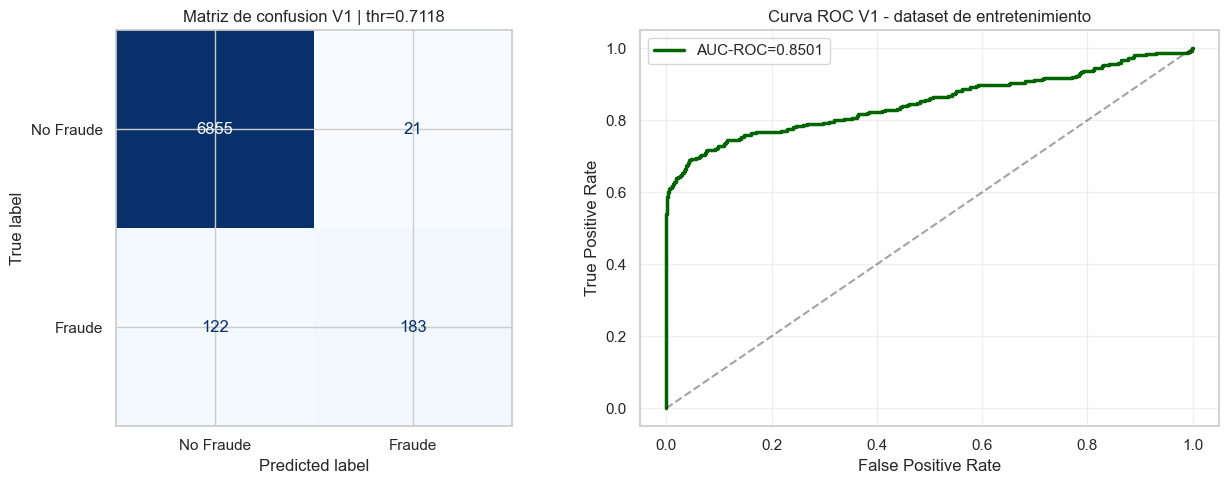

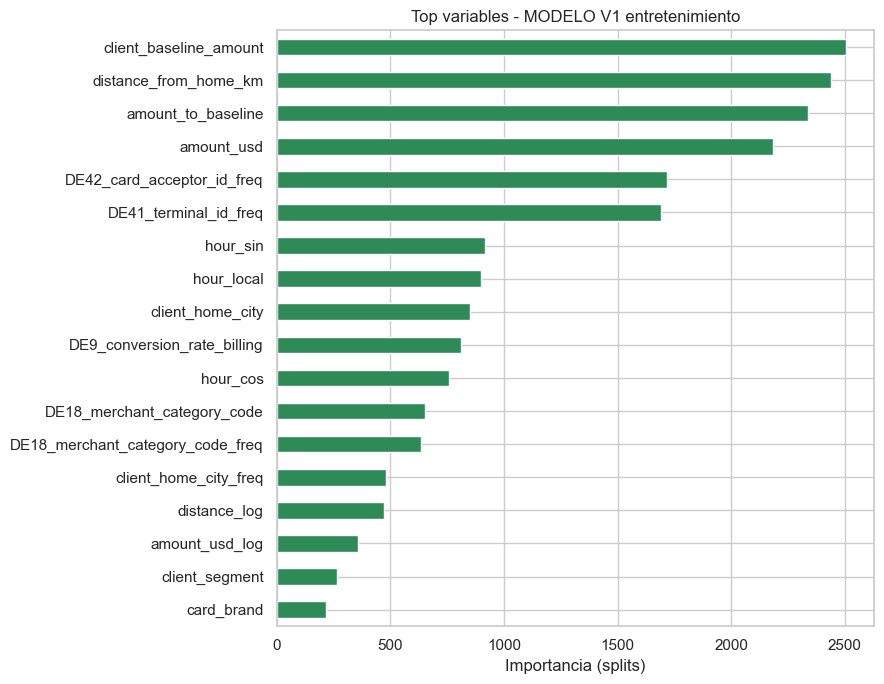

Top 10 variables V1:
client_baseline_amount         2503
distance_from_home_km          2440
amount_to_baseline             2337
amount_usd                     2183
DE42_card_acceptor_id_freq     1717
DE41_terminal_id_freq          1692
hour_sin                        917
hour_local                      898
client_home_city                851
DE9_conversion_rate_billing     811


In [30]:
results_v1 = evaluate_v1(model_v1, X_val_v1, y_val_v1, X_test_v1, y_test_v1)

importance_v1 = (
    pd.Series(model_v1.feature_importances_, index=FINAL_FEATURES_V1)
    .sort_values(ascending=True)
    .tail(18)
)

fig, ax = plt.subplots(figsize=(9, 7))
importance_v1.plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("Top variables - MODELO V1 entretenimiento")
ax.set_xlabel("Importancia (splits)")
plt.tight_layout()
plt.show()

print("Top 10 variables V1:")
print(importance_v1.sort_values(ascending=False).head(10).to_string())


### Resultados y conclusion V1

El MODELO V1 obtiene estos resultados sobre el test de junio:

| Metrica | Valor |
|---|---:|
| AUC-ROC | 0.8501 |
| F1-score | 0.7191 |
| Precision fraude | 0.8971 |
| Recall fraude | 0.6000 |

La matriz de confusion indica:

| Valor real / prediccion | Predice No Fraude | Predice Fraude |
|---|---:|---:|
| Real No Fraude | 6855 | 21 |
| Real Fraude | 122 | 183 |

Interpretacion operativa:

- **TP = 183**: fraudes reales detectados correctamente.
- **FN = 122**: fraudes reales que el modelo dejo escapar.
- **FP = 21**: transacciones legitimas marcadas como fraude.
- **TN = 6855**: transacciones legitimas clasificadas correctamente.

De los **305 fraudes reales** de junio, el modelo detecta **183** y deja escapar **122**. Esto equivale a un recall de **60.0%**. La precision de fraude es alta (**89.7%**), porque de las alertas emitidas como fraude, la mayoria son fraude real. Los falsos positivos son bajos: **21** casos sobre **6876** transacciones legitimas.

Como conclusion, el MODELO V1 tiene buen poder de separacion inicial para entretenimiento, con **AUC-ROC 0.8501** y **F1-score 0.7191**. Su principal debilidad es que todavia no captura el 40.0% de los fraudes reales, por lo que no deberia considerarse listo para produccion sin mejoras adicionales de recall.


---
## MODELO V2 - objetivo

El MODELO V2 mantiene el objetivo de detectar fraude en entretenimiento, pero separa dos familias de estrategias:

1. **Agresivas:** buscan recall cercano a 90%, aunque pueden generar demasiadas alertas falsas.
2. **Conservadoras:** maximizan recall solo si la precision de validacion se mantiene cerca de 90% o si se respeta un presupuesto fijo de alertas.

La meta operativa de esta iteracion es encontrar una alternativa que detecte mas fraudes que el baseline V1 del mismo split, pero sin repetir el problema del V2 agresivo anterior, que generaba miles de falsos positivos.

Para V2 el test es el ultimo trimestre del dataset: abril, mayo y junio. Enero-febrero se usa para entrenar y marzo para validacion/threshold.


In [4]:
import lightgbm as lgb

RECALL_TARGET_V2 = 0.90
PRECISION_FLOOR_V2 = 0.90
ALERT_BUDGET_RATE_V2 = 0.03
SPW_MULTIPLIERS_V2 = [1.0, 1.5, 2.0]


def prepare_v2_splits(df_entertainment):
    """Prepara train enero-febrero, validation marzo y test abril-junio."""
    df_model, dropped_cols, constant_cols = clean_entertainment_columns(df_entertainment)
    train = df_model[df_model["month"].isin([1, 2])].copy()
    val = df_model[df_model["month"] == 3].copy()
    test = df_model[df_model["month"].isin([4, 5, 6])].copy()
    return train, val, test, dropped_cols, constant_cols


def make_lgb_dataset_v2(X, y, categorical_features, reference=None):
    return lgb.Dataset(
        X,
        label=y,
        categorical_feature=categorical_features,
        reference=reference,
        free_raw_data=False,
    )


def _as_probability(preds):
    preds = np.asarray(preds, dtype=float)
    if np.nanmin(preds) < 0 or np.nanmax(preds) > 1:
        preds = 1.0 / (1.0 + np.exp(-preds))
    return preds


def _confusion_counts(y_true, proba, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (_as_probability(proba) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return int(tn), int(fp), int(fn), int(tp), y_pred


def fp_alert_ratio(fp, tp):
    alerts = tp + fp
    return float(fp / alerts) if alerts > 0 else 0.0


def _metrics_at_threshold(y_true, proba, threshold):
    proba = _as_probability(proba)
    tn, fp, fn, tp, y_pred = _confusion_counts(y_true, proba, threshold)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, proba) if len(np.unique(y_true)) == 2 else np.nan
    fp_ratio = fp_alert_ratio(fp, tp)
    return {
        "threshold": float(threshold),
        "auc_roc": float(auc),
        "f1": float(f1),
        "precision": float(precision),
        "recall": float(recall),
        "fp_ratio": float(fp_ratio),
        "alerts": int(tp + fp),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }


def _threshold_candidates(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, _as_probability(proba))
    candidates = []
    for idx, threshold in enumerate(thresholds):
        p = float(precision[idx])
        r = float(recall[idx])
        f1_val = 2 * p * r / (p + r + 1e-12)
        candidates.append({
            "threshold": float(threshold),
            "validation_precision": p,
            "validation_recall": r,
            "validation_fp_ratio": 1.0 - p if p > 0 else 1.0,
            "validation_f1": float(f1_val),
        })
    return candidates


def _empty_threshold_info(status):
    return {
        "threshold_status": status,
        "validation_precision": 0.0,
        "validation_recall": 0.0,
        "validation_fp_ratio": 0.0,
        "validation_f1": 0.0,
        "validation_alerts": 0,
    }


def select_threshold_for_recall_target(y_true, proba, recall_target=RECALL_TARGET_V2):
    candidates = _threshold_candidates(y_true, proba)
    if len(candidates) == 0:
        return 0.5, _empty_threshold_info("recall_target_no_threshold")

    feasible = [row for row in candidates if row["validation_recall"] >= recall_target]
    if feasible:
        best = sorted(
            feasible,
            key=lambda row: (row["validation_fp_ratio"], -row["validation_recall"], -row["validation_precision"], -row["validation_f1"]),
        )[0]
        status = "recall_target_met"
    else:
        best = sorted(
            candidates,
            key=lambda row: (-row["validation_recall"], row["validation_fp_ratio"], -row["validation_precision"], -row["validation_f1"]),
        )[0]
        status = "recall_target_not_met"

    return best["threshold"], {"threshold_status": status, **{k: v for k, v in best.items() if k != "threshold"}}


def select_threshold_for_precision_floor(y_true, proba, precision_floor=PRECISION_FLOOR_V2):
    candidates = _threshold_candidates(y_true, proba)
    if len(candidates) == 0:
        return 0.5, _empty_threshold_info("precision_floor_no_threshold")

    feasible = [row for row in candidates if row["validation_precision"] >= precision_floor]
    if feasible:
        best = sorted(
            feasible,
            key=lambda row: (-row["validation_recall"], row["validation_fp_ratio"], -row["validation_f1"], -row["validation_precision"]),
        )[0]
        status = "precision_floor_met"
    else:
        best = sorted(
            candidates,
            key=lambda row: (-row["validation_precision"], -row["validation_recall"], -row["validation_f1"]),
        )[0]
        status = "precision_floor_not_met"

    return best["threshold"], {"threshold_status": status, **{k: v for k, v in best.items() if k != "threshold"}}


def select_threshold_for_alert_budget(y_true, proba, alert_rate=ALERT_BUDGET_RATE_V2):
    proba = _as_probability(proba)
    if len(proba) == 0:
        return 0.5, _empty_threshold_info("alert_budget_no_scores")

    top_n = max(1, int(np.ceil(len(proba) * alert_rate)))
    order = np.argsort(proba)[::-1]
    threshold = float(proba[order[top_n - 1]])
    metrics = _metrics_at_threshold(y_true, proba, threshold)
    return threshold, {
        "threshold_status": "alert_budget_fixed",
        "validation_precision": metrics["precision"],
        "validation_recall": metrics["recall"],
        "validation_fp_ratio": metrics["fp_ratio"],
        "validation_f1": metrics["f1"],
        "validation_alerts": metrics["alerts"],
    }


def select_threshold_by_policy(y_true, proba, threshold_policy, threshold_value):
    if threshold_policy == "recall_target":
        return select_threshold_for_recall_target(y_true, proba, recall_target=threshold_value)
    if threshold_policy == "precision_floor":
        return select_threshold_for_precision_floor(y_true, proba, precision_floor=threshold_value)
    if threshold_policy == "alert_budget":
        return select_threshold_for_alert_budget(y_true, proba, alert_rate=threshold_value)
    raise ValueError(f"Politica de threshold no soportada: {threshold_policy}")


def _score_at_fixed_threshold(y_true, preds, threshold=0.5):
    metrics = _metrics_at_threshold(y_true, _as_probability(preds), threshold)
    return metrics


def _top_alert_metrics(y_true, proba, alert_rate):
    y_true = np.asarray(y_true).astype(int)
    proba = _as_probability(proba)
    top_n = max(1, int(np.ceil(len(proba) * alert_rate)))
    order = np.argsort(proba)[::-1][:top_n]
    tp = int(y_true[order].sum())
    precision = tp / top_n
    recall = tp / max(1, int(y_true.sum()))
    return precision, recall, top_n


def feval_fp_ratio_penalty(preds, dataset):
    y_true = dataset.get_label().astype(int)
    m = _score_at_fixed_threshold(y_true, preds, threshold=0.5)
    score = m["recall"] - m["fp_ratio"]
    return "fp_ratio_penalty", score, True


def feval_recall90_fp_ratio(preds, dataset):
    y_true = dataset.get_label().astype(int)
    proba = _as_probability(preds)
    _threshold, val_info = select_threshold_for_recall_target(y_true, proba, recall_target=RECALL_TARGET_V2)
    score = (1.0 - val_info["validation_fp_ratio"]) - max(0.0, RECALL_TARGET_V2 - val_info["validation_recall"]) * 2.0
    return "recall90_fp_ratio", score, True


def feval_balanced_recall_fp(preds, dataset):
    y_true = dataset.get_label().astype(int)
    m = _score_at_fixed_threshold(y_true, preds, threshold=0.5)
    score = 0.65 * m["recall"] + 0.35 * (1.0 - m["fp_ratio"]) - max(0.0, 0.75 - m["recall"]) * 0.50
    return "balanced_recall_fp", score, True


def feval_fbeta_recall(preds, dataset):
    y_true = dataset.get_label().astype(int)
    m = _score_at_fixed_threshold(y_true, preds, threshold=0.5)
    beta = 2.0
    p = m["precision"]
    r = m["recall"]
    fbeta = (1 + beta**2) * p * r / ((beta**2 * p) + r + 1e-12)
    return "fbeta_recall", float(fbeta), True


def feval_recall_at_precision_90(preds, dataset):
    y_true = dataset.get_label().astype(int)
    proba = _as_probability(preds)
    _threshold, val_info = select_threshold_for_precision_floor(y_true, proba, precision_floor=PRECISION_FLOOR_V2)
    precision_gap = max(0.0, PRECISION_FLOOR_V2 - val_info["validation_precision"])
    score = val_info["validation_recall"] - 3.0 * precision_gap
    return "recall_at_precision_90", float(score), True


def feval_recall_at_alert_budget_3pct(preds, dataset):
    y_true = dataset.get_label().astype(int)
    precision, recall, _top_n = _top_alert_metrics(y_true, preds, ALERT_BUDGET_RATE_V2)
    score = recall + 0.05 * precision
    return "recall_at_alert_budget_3pct", float(score), True


FEVAL_STRATEGIES_V2 = {
    "fp_ratio_penalty": {
        "feval": feval_fp_ratio_penalty,
        "family": "agresivo",
        "threshold_policy": "recall_target",
        "threshold_value": RECALL_TARGET_V2,
    },
    "recall90_fp_ratio": {
        "feval": feval_recall90_fp_ratio,
        "family": "agresivo",
        "threshold_policy": "recall_target",
        "threshold_value": RECALL_TARGET_V2,
    },
    "balanced_recall_fp": {
        "feval": feval_balanced_recall_fp,
        "family": "agresivo",
        "threshold_policy": "recall_target",
        "threshold_value": RECALL_TARGET_V2,
    },
    "fbeta_recall": {
        "feval": feval_fbeta_recall,
        "family": "agresivo",
        "threshold_policy": "recall_target",
        "threshold_value": RECALL_TARGET_V2,
    },
    "recall_at_precision_90": {
        "feval": feval_recall_at_precision_90,
        "family": "conservador",
        "threshold_policy": "precision_floor",
        "threshold_value": PRECISION_FLOOR_V2,
    },
    "recall_at_alert_budget_3pct": {
        "feval": feval_recall_at_alert_budget_3pct,
        "family": "conservador",
        "threshold_policy": "alert_budget",
        "threshold_value": ALERT_BUDGET_RATE_V2,
    },
}

FEVAL_DESCRIPTIONS_V2 = pd.DataFrame([
    {"feval": "fp_ratio_penalty", "familia": "agresivo", "objetivo": "Castiga alertas falsas usando recall - FP ratio, con threshold recall>=90%."},
    {"feval": "recall90_fp_ratio", "familia": "agresivo", "objetivo": "Busca recall >= 90% y luego minimiza FP ratio."},
    {"feval": "balanced_recall_fp", "familia": "agresivo", "objetivo": "Balancea recall con baja proporcion de falsas alertas."},
    {"feval": "fbeta_recall", "familia": "agresivo", "objetivo": "Usa F2 para favorecer deteccion de fraude."},
    {"feval": "recall_at_precision_90", "familia": "conservador", "objetivo": "Maximiza recall solo entre thresholds con precision de validacion >= 90%."},
    {"feval": "recall_at_alert_budget_3pct", "familia": "conservador", "objetivo": "Maximiza recall dentro de un presupuesto fijo de alertas del 3% en validacion."},
])


def evaluate_v2_strategy(model, strategy_name, strategy_cfg, spw_multiplier, scale_pos_weight, X_val, y_val, X_test, y_test):
    val_proba = model.predict(X_val, num_iteration=model.best_iteration)
    threshold, validation_info = select_threshold_by_policy(
        y_val,
        val_proba,
        strategy_cfg["threshold_policy"],
        strategy_cfg["threshold_value"],
    )
    test_proba = model.predict(X_test, num_iteration=model.best_iteration)
    test_metrics = _metrics_at_threshold(y_test, test_proba, threshold)

    row = {
        "strategy": strategy_name,
        "strategy_family": strategy_cfg["family"],
        "threshold_policy": strategy_cfg["threshold_policy"],
        "threshold_value": float(strategy_cfg["threshold_value"]),
        "spw_multiplier": float(spw_multiplier),
        "scale_pos_weight": float(scale_pos_weight),
        "best_iteration": int(model.best_iteration or 0),
        **validation_info,
        **test_metrics,
    }
    return row


def train_one_v2_strategy(strategy_name, strategy_cfg, spw_multiplier, base_spw, train_set, valid_set, X_val, y_val, X_test, y_test):
    scale_pos_weight = base_spw * spw_multiplier
    params = {
        "objective": "binary",
        "metric": "None",
        "learning_rate": 0.03,
        "num_leaves": 31,
        "min_data_in_leaf": 20,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "lambda_l1": 0.10,
        "lambda_l2": 0.50,
        "scale_pos_weight": scale_pos_weight,
        "verbosity": -1,
        "seed": RANDOM_STATE,
        "num_threads": -1,
    }
    model = lgb.train(
        params,
        train_set,
        num_boost_round=700,
        valid_sets=[valid_set],
        valid_names=["validation"],
        feval=strategy_cfg["feval"],
        callbacks=[lgb.early_stopping(stopping_rounds=60, first_metric_only=True, verbose=False)],
    )
    return evaluate_v2_strategy(model, strategy_name, strategy_cfg, spw_multiplier, scale_pos_weight, X_val, y_val, X_test, y_test), model


def train_v2_strategies(X_train, y_train, X_val, y_val, X_test, y_test, categorical_features):
    train_set = make_lgb_dataset_v2(X_train, y_train, categorical_features)
    valid_set = make_lgb_dataset_v2(X_val, y_val, categorical_features, reference=train_set)
    base_spw = int((y_train == 0).sum()) / max(int(y_train.sum()), 1)

    rows = []
    models = {}
    for strategy_name, strategy_cfg in FEVAL_STRATEGIES_V2.items():
        for multiplier in SPW_MULTIPLIERS_V2:
            row, model = train_one_v2_strategy(
                strategy_name, strategy_cfg, multiplier, base_spw,
                train_set, valid_set, X_val, y_val, X_test, y_test,
            )
            rows.append(row)
            models[(strategy_name, multiplier)] = model

    results = pd.DataFrame(rows)

    conservative = results[results["strategy_family"] == "conservador"].copy()
    conservative_feasible = conservative[conservative["validation_precision"] >= PRECISION_FLOOR_V2].copy()
    if len(conservative_feasible) > 0:
        best_row = conservative_feasible.sort_values(
            ["validation_recall", "validation_fp_ratio", "validation_f1", "validation_precision"],
            ascending=[False, True, False, False],
        ).iloc[0]
        selection_note = "Se eligio V2 conservador usando solo validacion: precision_val >= 0.90, mayor recall_val y menor FP ratio_val."
    else:
        best_row = conservative.sort_values(
            ["validation_precision", "validation_recall", "validation_f1", "validation_fp_ratio"],
            ascending=[False, False, False, True],
        ).iloc[0]
        selection_note = "Ninguna estrategia conservadora alcanzo precision_val >= 0.90; se eligio la de mayor precision_val."

    aggressive = results[results["strategy_family"] == "agresivo"].copy()
    aggressive_reference_row = aggressive.sort_values(
        ["recall", "fp_ratio", "f1"],
        ascending=[False, True, False],
    ).iloc[0]

    best_key = (best_row["strategy"], best_row["spw_multiplier"])
    best_model = models[best_key]
    return results, best_row, best_model, selection_note, base_spw, aggressive_reference_row


def evaluate_v1_baseline_same_split(X_train, y_train, X_val, y_val, X_test, y_test, categorical_features):
    model, spw = train_lgbm_v1(X_train, y_train, categorical_features)
    val_proba = model.predict_proba(X_val)[:, 1]
    threshold, val_f1, val_precision, val_recall = _best_f1_threshold(y_val, val_proba)
    test_proba = model.predict_proba(X_test)[:, 1]
    metrics = _metrics_at_threshold(y_test, test_proba, threshold)
    return {
        "model": "V1 baseline mismo split",
        "threshold": threshold,
        "validation_f1": val_f1,
        "validation_precision": val_precision,
        "validation_recall": val_recall,
        "validation_fp_ratio": 1.0 - val_precision if val_precision > 0 else 1.0,
        "scale_pos_weight": spw,
        **metrics,
    }


## Funciones feval evaluadas

Cada estrategia V2 usa una funcion `feval` distinta para guiar LightGBM. Las estrategias agresivas mantienen el objetivo de recall alto; las conservadoras agregan restricciones operativas para controlar falsos positivos.


In [5]:
display(FEVAL_DESCRIPTIONS_V2)

v2_train_df, v2_val_df, v2_test_df, dropped_cols_v2, constant_cols_v2 = prepare_v2_splits(df_entertainment_v1)
X_train_v2, y_train_v2, X_val_v2, y_val_v2, X_test_v2, y_test_v2, FINAL_FEATURES_V2, CATEGORICAL_FEATURES_V2 = build_v1_features(
    v2_train_df, v2_val_df, v2_test_df
)

assert loaded_entertainment_path_v1.name == "dataset de entretenimiento.csv"
assert set(v2_test_df["month"].unique().tolist()) == {4, 5, 6}
assert not set(LEAKAGE_COLS).intersection(FINAL_FEATURES_V2)

print("Split V2:")
for name, frame in [("Train enero-febrero", v2_train_df), ("Validation marzo", v2_val_df), ("Test abril-junio", v2_test_df)]:
    print(f"  {name}: {len(frame):>6,} tx | fraudes={int(frame[TARGET].sum()):>4} | no fraudes={int((~frame[TARGET]).sum()):>6} | tasa={frame[TARGET].mean()*100:.3f}%")

print()
print(f"Features V2 ({len(FINAL_FEATURES_V2)}):")
print(FINAL_FEATURES_V2)
print(f"Categoricas V2: {CATEGORICAL_FEATURES_V2}")

v2_results_df, best_v2_row, best_v2_model, best_v2_selection_note, base_spw_v2, aggressive_v2_row = train_v2_strategies(
    X_train_v2, y_train_v2, X_val_v2, y_val_v2, X_test_v2, y_test_v2, CATEGORICAL_FEATURES_V2
)

v1_same_split_metrics = evaluate_v1_baseline_same_split(
    X_train_v2, y_train_v2, X_val_v2, y_val_v2, X_test_v2, y_test_v2, CATEGORICAL_FEATURES_V2
)

print()
print(f"scale_pos_weight base V2 = {base_spw_v2:.2f}")
print(best_v2_selection_note)


,feval,familia,objetivo
0,fp_ratio_penalty,agresivo,Castiga alertas falsas usando recall - FP rati...
1,recall90_fp_ratio,agresivo,Busca recall >= 90% y luego minimiza FP ratio.
2,balanced_recall_fp,agresivo,Balancea recall con baja proporcion de falsas ...
3,fbeta_recall,agresivo,Usa F2 para favorecer deteccion de fraude.
4,recall_at_precision_90,conservador,Maximiza recall solo entre thresholds con prec...
5,recall_at_alert_budget_3pct,conservador,Maximiza recall dentro de un presupuesto fijo ...


Split V2:
  Train enero-febrero: 14,958 tx | fraudes= 691 | no fraudes= 14267 | tasa=4.620%
  Validation marzo:  7,673 tx | fraudes= 350 | no fraudes=  7323 | tasa=4.561%
  Test abril-junio: 22,460 tx | fraudes= 949 | no fraudes= 21511 | tasa=4.225%

Features V2 (33):
['amount_usd', 'client_baseline_amount', 'distance_from_home_km', 'hour_local', 'DE9_conversion_rate_billing', 'amount_to_baseline', 'amount_usd_log', 'high_amount_vs_baseline', 'distance_log', 'is_far_from_home', 'is_night', 'is_weekend', 'hour_sin', 'hour_cos', 'is_card_not_present', 'pin_present', 'emv_present', 'is_international_int', 'DE41_terminal_id_freq', 'DE42_card_acceptor_id_freq', 'client_home_city_freq', 'DE18_merchant_category_code_freq', 'channel', 'DE18_merchant_category_code', 'DE22_pos_entry_mode', 'DE25_pos_condition_code', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE60_pos_terminal_type', 'client_segment', 'card_brand', 'client_home_city', 'is_international']
Categoricas V2: ['channel', 'DE18_


scale_pos_weight base V2 = 20.65
Se eligio V2 conservador usando solo validacion: precision_val >= 0.90, mayor recall_val y menor FP ratio_val.


## Comparativo de estrategias V2

La tabla compara cada funcion `feval`, su familia, la politica de threshold y el peso de clase. La columna `fp_ratio` equivale a `FP / (TP + FP)` en test; las columnas `validation_*` muestran el criterio usado para seleccionar el V2 conservador sin mirar el test.


In [6]:
comparison_cols_v2 = [
    "strategy", "strategy_family", "threshold_policy", "spw_multiplier", "scale_pos_weight",
    "threshold", "auc_roc", "f1", "precision", "recall", "fp_ratio", "alerts",
    "tp", "fp", "fn", "tn", "best_iteration", "threshold_status",
    "validation_precision", "validation_recall", "validation_fp_ratio", "validation_alerts",
]

v2_comparison_display = v2_results_df[comparison_cols_v2].copy()
for col in [
    "scale_pos_weight", "threshold", "auc_roc", "f1", "precision", "recall", "fp_ratio",
    "validation_precision", "validation_recall", "validation_fp_ratio",
]:
    v2_comparison_display[col] = v2_comparison_display[col].astype(float).round(4)

display(v2_comparison_display.sort_values(
    ["strategy_family", "validation_precision", "validation_recall", "fp_ratio"],
    ascending=[True, False, False, True],
))

best_v2_summary = best_v2_row.to_dict()
aggressive_v2_summary = aggressive_v2_row.to_dict()
print("Referencia V2 agresiva anterior:")
print(f"  feval: {aggressive_v2_summary['strategy']}")
print(f"  threshold: {aggressive_v2_summary['threshold']:.4f}")
print(f"  Precision: {aggressive_v2_summary['precision']:.4f} | Recall: {aggressive_v2_summary['recall']:.4f} | FP={int(aggressive_v2_summary['fp'])} | TP={int(aggressive_v2_summary['tp'])}")
print()
print("Mejor estrategia V2 conservadora:")
print(f"  feval: {best_v2_summary['strategy']}")
print(f"  politica threshold: {best_v2_summary['threshold_policy']}")
print(f"  scale_pos_weight: {best_v2_summary['scale_pos_weight']:.4f}")
print(f"  threshold: {best_v2_summary['threshold']:.4f}")
print(f"  AUC-ROC: {best_v2_summary['auc_roc']:.4f}")
print(f"  F1-score: {best_v2_summary['f1']:.4f}")
print(f"  Precision: {best_v2_summary['precision']:.4f}")
print(f"  Recall: {best_v2_summary['recall']:.4f}")
print(f"  FP ratio: {best_v2_summary['fp_ratio']:.4f}")
print(f"  TP={int(best_v2_summary['tp'])} FP={int(best_v2_summary['fp'])} FN={int(best_v2_summary['fn'])} TN={int(best_v2_summary['tn'])}")


,strategy,strategy_family,threshold_policy,spw_multiplier,scale_pos_weight,threshold,auc_roc,f1,precision,recall,...,tp,fp,fn,tn,best_iteration,threshold_status,validation_precision,validation_recall,validation_fp_ratio,validation_alerts
4,recall90_fp_ratio,agresivo,recall_target,1.5,30.9703,0.1467,0.8632,0.1710,0.0954,0.8240,...,782,7416,167,14095,117,recall_target_met,0.1111,0.9000,0.8889,NaN
7,balanced_recall_fp,agresivo,recall_target,1.5,30.9703,0.1306,0.8647,0.1577,0.0870,0.8398,...,797,8359,152,13152,30,recall_target_met,0.1006,0.9000,0.8994,NaN
10,fbeta_recall,agresivo,recall_target,1.5,30.9703,0.1306,0.8647,0.1577,0.0870,0.8398,...,797,8359,152,13152,30,recall_target_met,0.1006,0.9000,0.8994,NaN
5,recall90_fp_ratio,agresivo,recall_target,2.0,41.2938,0.1033,0.8644,0.1579,0.0870,0.8514,...,808,8479,141,13032,10,recall_target_met,0.0987,0.9000,0.9013,NaN
1,fp_ratio_penalty,agresivo,recall_target,1.5,30.9703,0.1241,0.8653,0.1545,0.0850,0.8472,...,804,8653,145,12858,27,recall_target_met,0.0969,0.9000,0.9031,NaN
11,fbeta_recall,agresivo,recall_target,2.0,41.2938,0.1440,0.8666,0.1554,0.0855,0.8567,...,813,8698,136,12813,29,recall_target_met,0.0966,0.9000,0.9034,NaN
8,balanced_recall_fp,agresivo,recall_target,2.0,41.2938,0.1559,0.8661,0.1540,0.0847,0.8462,...,803,8675,146,12836,57,recall_target_met,0.0966,0.9000,0.9034,NaN
2,fp_ratio_penalty,agresivo,recall_target,2.0,41.2938,0.1366,0.8667,0.1526,0.0837,0.8588,...,815,8919,134,12592,25,recall_target_met,0.0948,0.9029,0.9052,NaN
3,recall90_fp_ratio,agresivo,recall_target,1.0,20.6469,0.0962,0.8638,0.1524,0.0837,0.8577,...,814,8916,135,12595,22,recall_target_met,0.0936,0.9000,0.9064,NaN
0,fp_ratio_penalty,agresivo,recall_target,1.0,20.6469,0.0975,0.8638,0.1460,0.0797,0.8609,...,817,9429,132,12082,29,recall_target_met,0.0892,0.9000,0.9108,NaN


Referencia V2 agresiva anterior:
  feval: balanced_recall_fp
  threshold: 0.0826
  Precision: 0.0783 | Recall: 0.8683 | FP=9694 | TP=824

Mejor estrategia V2 conservadora:
  feval: recall_at_alert_budget_3pct
  politica threshold: alert_budget
  scale_pos_weight: 20.6469
  threshold: 0.7745
  AUC-ROC: 0.8626
  F1-score: 0.7014
  Precision: 0.9008
  Recall: 0.5743
  FP ratio: 0.0992
  TP=545 FP=60 FN=404 TN=21451


## Mejor estrategia V2 conservadora

Esta seccion muestra el balance entre falsas alertas, recall y precision para todas las estrategias, y la matriz de confusion de la estrategia conservadora seleccionada.


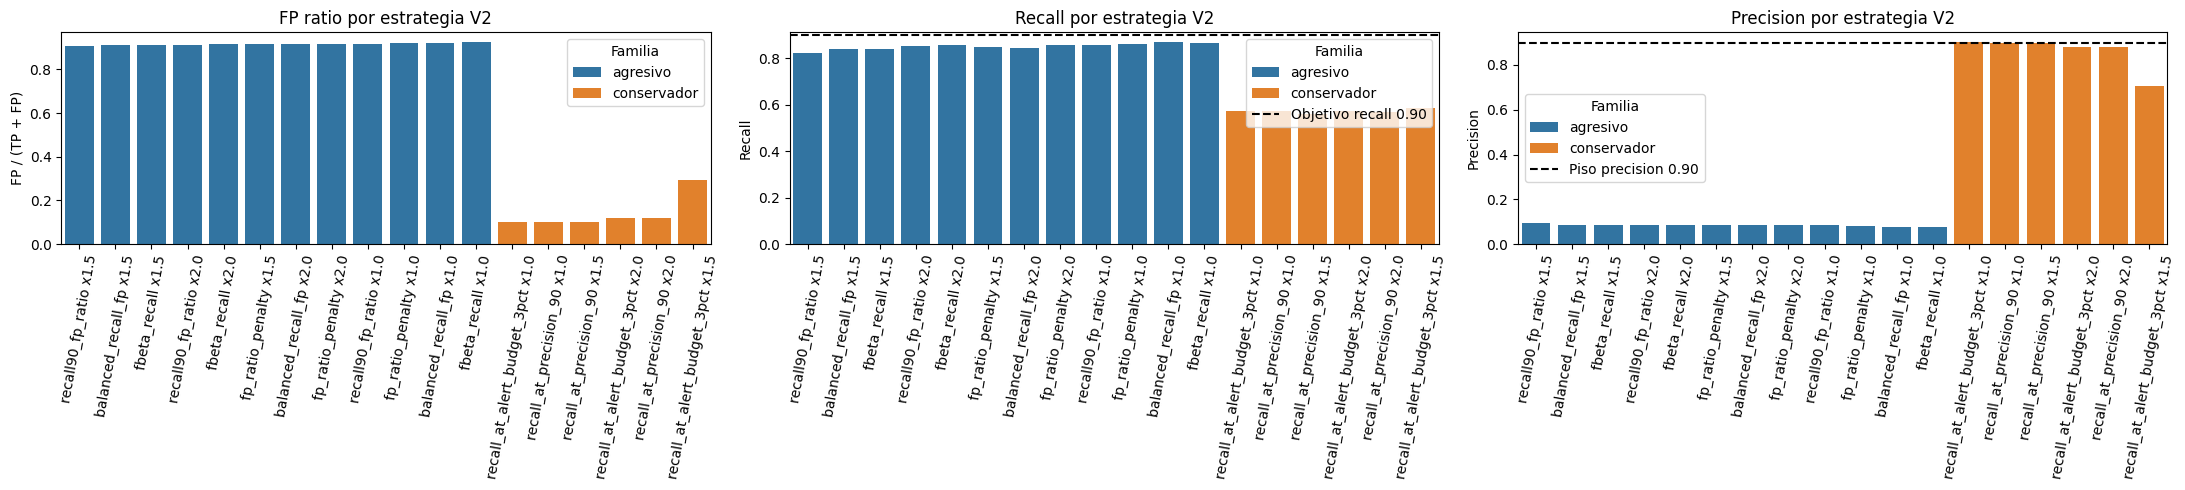

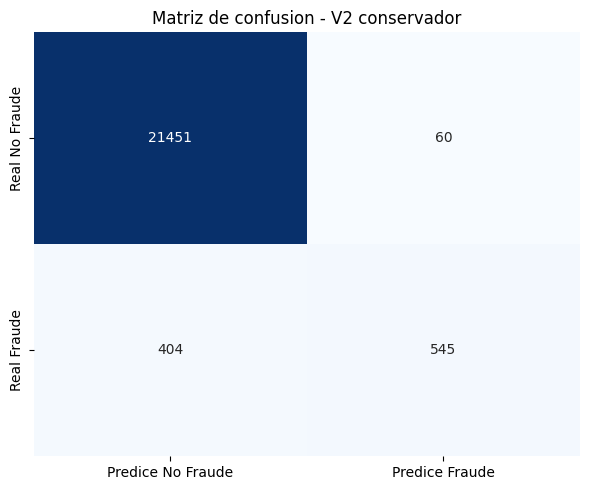

In [7]:
plot_results = v2_results_df.copy()
plot_results["strategy_label"] = plot_results["strategy"] + " x" + plot_results["spw_multiplier"].astype(str)
plot_results = plot_results.sort_values(["strategy_family", "fp_ratio"], ascending=[True, True])

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
sns.barplot(data=plot_results, x="strategy_label", y="fp_ratio", hue="strategy_family", dodge=False, ax=axes[0])
axes[0].set_title("FP ratio por estrategia V2")
axes[0].set_xlabel("")
axes[0].set_ylabel("FP / (TP + FP)")
axes[0].tick_params(axis="x", rotation=80)
axes[0].legend(title="Familia")

sns.barplot(data=plot_results, x="strategy_label", y="recall", hue="strategy_family", dodge=False, ax=axes[1])
axes[1].axhline(RECALL_TARGET_V2, color="black", linestyle="--", label="Objetivo recall 0.90")
axes[1].set_title("Recall por estrategia V2")
axes[1].set_xlabel("")
axes[1].set_ylabel("Recall")
axes[1].tick_params(axis="x", rotation=80)
axes[1].legend(title="Familia")

sns.barplot(data=plot_results, x="strategy_label", y="precision", hue="strategy_family", dodge=False, ax=axes[2])
axes[2].axhline(PRECISION_FLOOR_V2, color="black", linestyle="--", label="Piso precision 0.90")
axes[2].set_title("Precision por estrategia V2")
axes[2].set_xlabel("")
axes[2].set_ylabel("Precision")
axes[2].tick_params(axis="x", rotation=80)
axes[2].legend(title="Familia")
plt.tight_layout()
plt.show()

best_cm = np.array([
    [int(best_v2_row["tn"]), int(best_v2_row["fp"])],
    [int(best_v2_row["fn"]), int(best_v2_row["tp"])],
])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predice No Fraude", "Predice Fraude"],
            yticklabels=["Real No Fraude", "Real Fraude"], ax=ax)
ax.set_title("Matriz de confusion - V2 conservador")
plt.tight_layout()
plt.show()


## Comparacion V1 vs V2

Para que la comparacion sea justa, se reevalua un baseline tipo V1 usando el mismo split de V2: train enero-febrero, validation marzo y test abril-junio. Tambien se conserva como referencia el V2 agresivo anterior, que detectaba mas fraude pero con demasiadas falsas alertas.


,modelo,threshold,AUC-ROC,F1-score,Precision,Recall,FP ratio,Alertas,TP,FP,FN,TN
0,V1 baseline mismo split,0.7753,0.8558,0.7012,0.9479,0.5564,0.0521,557,528,29,421,21482
1,V2 agresivo anterior,0.0826,0.8640,0.1437,0.0783,0.8683,0.9217,10518,824,9694,125,11817
2,V2 conservador nuevo,0.7745,0.8626,0.7014,0.9008,0.5743,0.0992,605,545,60,404,21451


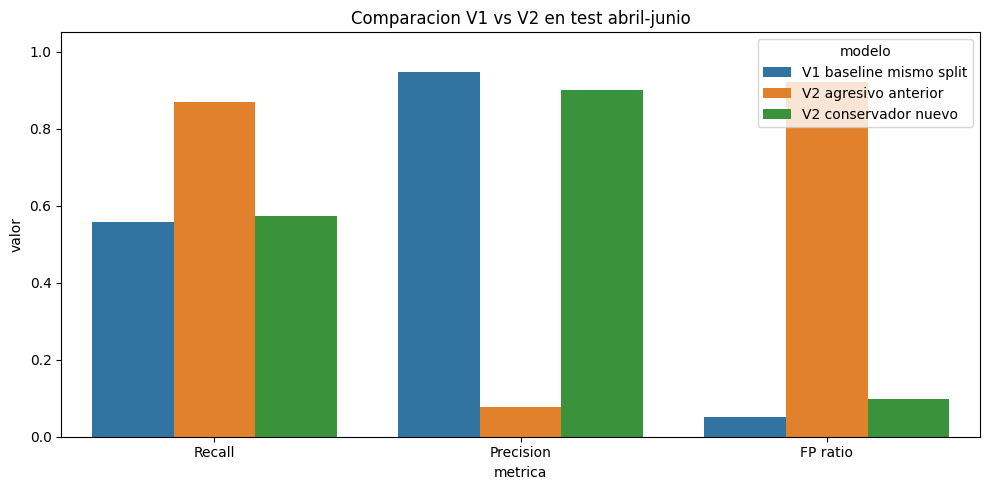

Valores V1 originales de junio como contexto:
  AUC-ROC=0.8501 | F1=0.7191 | Precision=0.8971 | Recall=0.6000 | TP=183 FP=21 FN=122 TN=6855


In [8]:
v1_same = v1_same_split_metrics
v2_aggressive = aggressive_v2_row.to_dict()
v2_best = best_v2_row.to_dict()

compare_v1_v2 = pd.DataFrame([
    {
        "modelo": "V1 baseline mismo split",
        "threshold": v1_same["threshold"],
        "AUC-ROC": v1_same["auc_roc"],
        "F1-score": v1_same["f1"],
        "Precision": v1_same["precision"],
        "Recall": v1_same["recall"],
        "FP ratio": v1_same["fp_ratio"],
        "Alertas": v1_same["alerts"],
        "TP": v1_same["tp"], "FP": v1_same["fp"], "FN": v1_same["fn"], "TN": v1_same["tn"],
    },
    {
        "modelo": "V2 agresivo anterior",
        "threshold": v2_aggressive["threshold"],
        "AUC-ROC": v2_aggressive["auc_roc"],
        "F1-score": v2_aggressive["f1"],
        "Precision": v2_aggressive["precision"],
        "Recall": v2_aggressive["recall"],
        "FP ratio": v2_aggressive["fp_ratio"],
        "Alertas": v2_aggressive["alerts"],
        "TP": v2_aggressive["tp"], "FP": v2_aggressive["fp"], "FN": v2_aggressive["fn"], "TN": v2_aggressive["tn"],
    },
    {
        "modelo": "V2 conservador nuevo",
        "threshold": v2_best["threshold"],
        "AUC-ROC": v2_best["auc_roc"],
        "F1-score": v2_best["f1"],
        "Precision": v2_best["precision"],
        "Recall": v2_best["recall"],
        "FP ratio": v2_best["fp_ratio"],
        "Alertas": v2_best["alerts"],
        "TP": v2_best["tp"], "FP": v2_best["fp"], "FN": v2_best["fn"], "TN": v2_best["tn"],
    },
])

for col in ["threshold", "AUC-ROC", "F1-score", "Precision", "Recall", "FP ratio"]:
    compare_v1_v2[col] = compare_v1_v2[col].astype(float).round(4)

display(compare_v1_v2)

plot_compare = compare_v1_v2.melt(
    id_vars="modelo",
    value_vars=["Recall", "Precision", "FP ratio"],
    var_name="metrica",
    value_name="valor",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_compare, x="metrica", y="valor", hue="modelo", ax=ax)
ax.set_title("Comparacion V1 vs V2 en test abril-junio")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("Valores V1 originales de junio como contexto:")
print("  AUC-ROC=0.8501 | F1=0.7191 | Precision=0.8971 | Recall=0.6000 | TP=183 FP=21 FN=122 TN=6855")


## Resultados y conclusion V2

El MODELO V2 evaluo estrategias agresivas y conservadoras con tres pesos de clase cada una. El test se mantiene como el ultimo trimestre del dataset de entretenimiento: abril, mayo y junio.

La seleccion final se hizo con validacion, no con test: **precision_val >= 0.90**, luego mayor recall de validacion y menor FP ratio de validacion.

### Mejor estrategia V2 conservadora

| Campo | Valor |
|---|---:|
| feval | recall_at_alert_budget_3pct |
| politica threshold | alert_budget |
| scale_pos_weight | 20.6469 |
| threshold | 0.7745 |
| AUC-ROC | 0.8626 |
| F1-score | 0.7014 |
| Precision | 0.9008 |
| Recall | 0.5743 |
| FP ratio = FP / (TP + FP) | 0.0992 |
| Alertas | 605 |

### Matriz de confusion V2 conservador

| Valor real / prediccion | Predice No Fraude | Predice Fraude |
|---|---:|---:|
| Real No Fraude | 21451 | 60 |
| Real Fraude | 404 | 545 |

Interpretacion operativa V2 conservador:

- **TP = 545**: fraudes reales detectados correctamente.
- **FN = 404**: fraudes reales que el modelo dejo escapar.
- **FP = 60**: transacciones legitimas marcadas como fraude.
- **TN = 21451**: transacciones legitimas clasificadas correctamente.

### Comparacion justa en abril-junio

| Modelo | AUC-ROC | F1-score | Precision | Recall | FP ratio | TP | FP | FN | TN |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| V1 baseline mismo split | 0.8558 | 0.7012 | 0.9479 | 0.5564 | 0.0521 | 528 | 29 | 421 | 21482 |
| V2 agresivo anterior | 0.8640 | 0.1437 | 0.0783 | 0.8683 | 0.9217 | 824 | 9694 | 125 | 11817 |
| V2 conservador nuevo | 0.8626 | 0.7014 | 0.9008 | 0.5743 | 0.0992 | 545 | 60 | 404 | 21451 |

### Conclusion

El V2 agresivo anterior detectaba muchos mas fraudes que V1 (**824 vs 528 TP**), pero era inviable operativamente porque subia los falsos positivos de **29 a 9694**.

El V2 conservador nuevo logra una mejora mas realista: detecta **545 fraudes vs 528 del V1 baseline** y controla los falsos positivos en **60**, muy lejos de los **9694** falsos positivos del V2 agresivo. No supera simultaneamente a V1 en todos los ejes, porque aumenta los FP de **29 a 60**, pero evita el colapso operativo del V2 anterior y ofrece un tradeoff defendible para revision manual.
